# Goal: Make Figure 5 for Egr1 paper: Egr1 binds differently in Males and Females.

In [1]:
import pycallingcards as cc
import pybedtools
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 150

In [2]:
Male_Egr1 = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_Egr1['group'] = 'Male_Egr1'
Male_Egr1
Male_WT = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_WT['group'] = 'Male_WT'
Male_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3056740,3056744,1,+,TCGTG/CTCACGGTGC/GTCA,Male_WT
1,chr1,3056740,3056744,2,+,TCGTG/CTCACGGTGC/TTGG,Male_WT
2,chr1,3057564,3057568,1,-,TCGTG/CTCACGGTGC/GTCA,Male_WT
3,chr1,3058419,3058423,6,-,TCGTG/CTCACGGTGC/CTTC,Male_WT
4,chr1,3175815,3175819,1,+,TCGTG/CTCACGGTGC/GAAG,Male_WT
...,...,...,...,...,...,...,...
1907938,chrY,90808770,90808774,23,-,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907939,chrY,90809800,90809804,1,-,TCGTG/CTAGGTGGAC/GTCA,Male_WT
1907940,chrY,90838013,90838017,4,+,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907941,chrY,90840202,90840206,1,-,TCGTG/CTAGGTGGAC/TCAG,Male_WT


In [3]:
Female_Egr1 = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_Egr1['group'] = 'Female_Egr1'
Female_Egr1
Female_WT = cc.rd.read_qbed('/lts/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_WT['group'] = 'Female_WT'
Female_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3031511,3031515,6,-,TCGTG/TTGTCCAACT/GTCA,Female_WT
1,chr1,3055972,3055976,1,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
2,chr1,3118633,3118637,54,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
3,chr1,3137382,3137386,1,-,TCGTG/TTGTCCAACT/GTTG,Female_WT
4,chr1,3152722,3152726,2,-,TCGTG/TTGTCCAACT/TCGA,Female_WT
...,...,...,...,...,...,...,...
1499371,chrY,90792082,90792086,1,-,TCGTG/GTCGTGCAAC/CATG,Female_WT
1499372,chrY,90799217,90799221,4,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499373,chrY,90800602,90800606,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499374,chrY,90807631,90807635,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT


In [12]:
# Load packages and set workind directory import os
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from gseapy import enrichr
from textwrap import wrap

# Set output directory
figure_output_dir = '/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/111225'
os.makedirs(figure_output_dir, exist_ok=True)

# Let's determine by Heatmaps which peaks to use. 

## I am currently using Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed" and "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed", but these were called with p TTAA = 0.001. 

## The peaks from "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed" are called using p TTAA = 0.05. 

Do this in mamba environment in unix.

Visualize some peaks

# Compare old with new peaks. Make sure TTAA 0.05 p value is correct to move forward with. 

In [21]:
import pandas as pd
import pycallingcards as cc  # Assuming you have already imported this earlier

# ======= Load Male Peak File =======
bed_file_male = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male_old = pd.read_csv(bed_file_male, sep='\t', header=None)
peak_data_Male_old.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions',
                              'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment',
                              'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted',
                              'pvalue_adj Reference']
print(f"✅ Loaded {len(peak_data_Male_old)} Male peaks")

# ======= Load Female Peak File =======
bed_file_female = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female_old = pd.read_csv(bed_file_female, sep='\t', header=None)
peak_data_Female_old.columns = peak_data_Male_old.columns  # use same headers
print(f"✅ Loaded {len(peak_data_Female_old)} Female peaks")

# ======= Annotate Male Peaks =======
peak_annotation_Male_old = cc.pp.annotation(
    peak_data_Male_old, 
    reference="mm10", 
    bedtools_path='/ref/rmlab/software/pycallingcards/bin'
)
peak_annotation_Male_old = cc.pp.combine_annotation(peak_data_Male_old, peak_annotation_Male_old)

# ======= Annotate Female Peaks =======
peak_annotation_Female_old = cc.pp.annotation(
    peak_data_Female_old, 
    reference="mm10", 
    bedtools_path='/ref/rmlab/software/pycallingcards/bin'
)
peak_annotation_Female_old = cc.pp.combine_annotation(peak_data_Female_old, peak_annotation_Female_old)

# Preview (optional)
peak_annotation_Male_old.head()
peak_annotation_Female_old.head()


✅ Loaded 11977 Male peaks
✅ Loaded 11772 Female peaks
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918


In [23]:
male_only_new_df

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2,peak_id
5,chr1,6215812,6216343,6216140.0,6,1,6,0.000125,0.000968,0.000003,...,0.044205,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,142988,chr1:6215812-6216343
10,chr1,6325622,6326060,6325848.0,6,2,6,0.000101,0.020449,0.000003,...,0.036065,NM_001195732,Alkal1,+,33271,NM_009826,Rb1cc1,+,-49519,chr1:6325622-6326060
16,chr1,10007144,10007703,10007488.0,8,1,7,0.000004,0.000020,0.000004,...,0.001841,NR_110971,Ppp1r42,-,0,NM_001277101,Cops5,-,16897,chr1:10007144-10007703
18,chr1,10300234,10300796,10300480.0,5,1,5,0.000060,0.005435,0.000002,...,0.021972,NM_177834,Cpa6,-,23923,NM_001102430,Arfgef1,-,-67565,chr1:10300234-10300796
26,chr1,12759016,12759454,12759245.0,5,1,4,0.000025,0.005435,0.000002,...,0.009512,NM_001198566,Sulf1,+,0,NR_045297,Gm17644,+,-85927,chr1:12759016-12759454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15585,chrX,164376247,164376706,164376503.0,7,2,6,0.000002,0.001486,0.000003,...,0.001037,NM_010216,Vegfd,+,0,NM_027153,Pir,+,-3235,chrX:164376247-164376706
15598,chrX,166661964,166662564,166662348.0,9,3,5,0.000004,0.001298,0.000004,...,0.001940,NR_046015,Gm1720,+,0,NM_019397,Egfl6,-,-76249,chrX:166661964-166662564
15600,chrX,167011149,167011562,167011349.0,7,3,4,0.000007,0.038804,0.000003,...,0.002823,NM_001101606,Gm8817,-,51887,NM_021278,Tmsb4x,-,195532,chrX:167011149-167011562
15613,chrX,169882972,169883414,169883172.0,7,2,8,0.000009,0.005862,0.000003,...,0.003729,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91629,chrX:169882972-169883414


In [22]:
# === Step 1: Add unique peak ID to both old and new dataframes ===

# For Male
peak_annotation_Male_old['peak_id'] = (
    peak_annotation_Male_old['Chr'] + ':' +
    peak_annotation_Male_old['Start'].astype(str) + '-' +
    peak_annotation_Male_old['End'].astype(str)
)

peak_annotation_Male['peak_id'] = (
    peak_annotation_Male['Chr'] + ':' +
    peak_annotation_Male['Start'].astype(str) + '-' +
    peak_annotation_Male['End'].astype(str)
)

# For Female
peak_annotation_Female_old['peak_id'] = (
    peak_annotation_Female_old['Chr'] + ':' +
    peak_annotation_Female_old['Start'].astype(str) + '-' +
    peak_annotation_Female_old['End'].astype(str)
)

peak_annotation_Female['peak_id'] = (
    peak_annotation_Female['Chr'] + ':' +
    peak_annotation_Female['Start'].astype(str) + '-' +
    peak_annotation_Female['End'].astype(str)
)

# === Step 2: Compare peak sets ===

# Male
male_only_in_new = set(peak_annotation_Male['peak_id']) - set(peak_annotation_Male_old['peak_id'])
male_only_in_old = set(peak_annotation_Male_old['peak_id']) - set(peak_annotation_Male['peak_id'])
male_shared = set(peak_annotation_Male['peak_id']) & set(peak_annotation_Male_old['peak_id'])

print(f"🧬 Male Peaks")
print(f"➡️ Only in NEW: {len(male_only_in_new)}")
print(f"⬅️ Only in OLD: {len(male_only_in_old)}")
print(f"✅ Shared: {len(male_shared)}")

# Female
female_only_in_new = set(peak_annotation_Female['peak_id']) - set(peak_annotation_Female_old['peak_id'])
female_only_in_old = set(peak_annotation_Female_old['peak_id']) - set(peak_annotation_Female['peak_id'])
female_shared = set(peak_annotation_Female['peak_id']) & set(peak_annotation_Female_old['peak_id'])

print(f"\n🧬 Female Peaks")
print(f"➡️ Only in NEW: {len(female_only_in_new)}")
print(f"⬅️ Only in OLD: {len(female_only_in_old)}")
print(f"✅ Shared: {len(female_shared)}")

# === Step 3: Optional — View full dataframes for exclusive peaks ===

male_only_new_df = peak_annotation_Male[peak_annotation_Male['peak_id'].isin(male_only_in_new)]
male_only_old_df = peak_annotation_Male_old[peak_annotation_Male_old['peak_id'].isin(male_only_in_old)]

female_only_new_df = peak_annotation_Female[peak_annotation_Female['peak_id'].isin(female_only_in_new)]
female_only_old_df = peak_annotation_Female_old[peak_annotation_Female_old['peak_id'].isin(female_only_in_old)]

# === Step 4: Save if needed ===

# male_only_new_df.to_csv("Male_peaks_only_in_new_090925.tsv", sep='\t', index=False)
# female_only_new_df.to_csv("Female_peaks_only_in_new_090925.tsv", sep='\t', index=False)


🧬 Male Peaks
➡️ Only in NEW: 3696
⬅️ Only in OLD: 51
✅ Shared: 11926

🧬 Female Peaks
➡️ Only in NEW: 2363
⬅️ Only in OLD: 12
✅ Shared: 11760


## look at peaks in 1 not in 2

In [19]:
# Get full DataFrame rows for peaks only in file 1
only_in_1_df = peaks1[peaks1['peak_id'].isin(only_in_1)]
print(only_in_1_df.head(10))  # show first 10 rows


import pybedtools

# Convert your peaks DataFrame to BedTool
peaks_bed = pybedtools.BedTool.from_dataframe(only_in_1_df[['Chr', 'Start', 'End', 'peak_id']])

# Load gene annotation BED file
genes_bed = pybedtools.BedTool("genes_mm10.bed")  # Replace with your gene BED file

# Find closest gene for each peak (distance reported)
closest = peaks_bed.closest(genes_bed, d=True)

# Convert back to DataFrame
closest_df = closest.to_dataframe(names=[
    'peak_chr', 'peak_start', 'peak_end', 'peak_id',
    'gene_chr', 'gene_start', 'gene_end', 'gene_name', 'distance'
])

print(closest_df.head(10))

Peaks only in file 1: 3696
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


ValueError: Can only compare identically-labeled (both index and columns) DataFrame objects

In [91]:
Egr1 = cc.rd.combine_qbed([Female_Egr1, Male_Egr1])
Egr1

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3042835,3042839,1,+,TCGTG/GCTACATGTG/CTGA,Male_Egr1
1,chr1,3045362,3045366,1,+,TCGTG/GCTACATGTG/ACAC,Male_Egr1
2,chr1,3046027,3046031,2,-,TCGTG/CACAGCGCGT/CTGA,Female_Egr1
3,chr1,3052537,3052541,1,+,TCGTG/ATACTCTAGG/GTCA,Male_Egr1
4,chr1,3055563,3055567,4,+,TCGTG/GTTATCGGAT/TCGA,Female_Egr1
...,...,...,...,...,...,...,...
3266333,chrY_JH584300_random,29071,29075,1,-,TCGTG/GACTTAATAC/CATG,Female_Egr1
3266334,chrY_JH584300_random,29071,29075,2,-,TCGTG/ATACTCTAGG/TTGG,Male_Egr1
3266335,chrY_JH584303_random,14934,14938,1,+,TCGTG/ATACTCTAGG/TCGA,Male_Egr1
3266336,chrY_JH584303_random,35487,35491,1,-,TCGTG/GACTTAATAC/CTGA,Female_Egr1


In [6]:
WT = cc.rd.combine_qbed([Male_WT, Female_WT])
WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3016345,3016349,2,+,TCGTG/GTCGTGCAAC/CTTC,Female_WT
1,chr1,3031511,3031515,6,-,TCGTG/TTGTCCAACT/GTCA,Female_WT
2,chr1,3031511,3031515,1,-,TCGTG/GTCGTGCAAC/TCGA,Female_WT
3,chr1,3031511,3031515,3,-,TCGTG/GTCGTGCAAC/TGGT,Female_WT
4,chr1,3042746,3042750,1,+,TCGTG/CGCTGGCTCT/TCAG,Female_WT
...,...,...,...,...,...,...,...
3407314,chrY_JH584303_random,35523,35527,1,-,TCGTG/TTGTCCAACT/TTGG,Female_WT
3407315,chrY_JH584303_random,37154,37158,1,+,TCGTG/GTCGTGCAAC/TTGG,Female_WT
3407316,chrY_JH584303_random,52539,52543,1,-,TCGTG/CGTTACACAG/TCGA,Male_WT
3407317,chrY_JH584303_random,117391,117395,1,-,TCGTG/CGTTACACAG/CATG,Male_WT


## Peaks in 1 (The new peaks)

In [9]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4808478,4809048,4808845.0,5,3,5,2.941727e-06,0.048679,0.000004,...,224.282487,1.343166e-03,NM_008866,Lypla1,+,0,NR_033530,Mrpl15,-,-22753
1,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.730557e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
4,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.309216e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14118,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.544437e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
14119,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.373781e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
14120,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.143628e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385
14121,chrX,169898268,169898791,169898468.0,10,9,9,4.302897e-10,0.014625,0.000008,...,248.481740,3.416187e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,76252


In [10]:
qbed = {"Male_Egr1": Male_Egr1, "Male_WT": Male_WT, "Female_Egr1": Female_Egr1, "Female_WT": Female_WT}
bed = {"peak_Male": peak_data_Male, "peak_Female": peak_data_Female}
cc.pl.WashU_browser_url(qbed = qbed, bed = bed, genome = 'mm10')

All qbed addressed
All bed addressed
Uploading files
Please click the following link to see the data on WashU Epigenome Browser directly.
https://epigenomegateway.wustl.edu/browser/?genome=mm10&hub=https://companion.epigenomegateway.org//task/be2cf767661106dca95f59129bc2f554/output//datahub.json


## Peaks in 2 (The old peaks)

In [7]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [8]:
qbed = {"Male_Egr1": Male_Egr1, "Male_WT": Male_WT, "Female_Egr1": Female_Egr1, "Female_WT": Female_WT}
bed = {"peak_Male": peak_data_Male, "peak_Female": peak_data_Female}
cc.pl.WashU_browser_url(qbed = qbed, bed = bed, genome = 'mm10')

All qbed addressed
All bed addressed
Uploading files
Please click the following link to see the data on WashU Epigenome Browser directly.
https://epigenomegateway.wustl.edu/browser/?genome=mm10&hub=https://companion.epigenomegateway.org//task/3d0b9231d05ea04cae3a853ec57c1cb4/output//datahub.json


# The peak numbers don't make sense. Let's confirm the original peaks were called as I found code for:

In [ ]:
# What if I now repeat this with my DE analysis, but instead of filtering out low count genes, I only remove outliers.
## I ran this code at the end of the ## C:/Users/loril/Documents/Egr1/Egr1_bulk_RNAseq/Egr1_KD_030525/Egr1KD_again_ButCombineEgr1KDsamples_only0filteredout_removeOutliers.Rmd file.

In [14]:
# Call Peaks separately
peak_data_Male = cc.pp.call_peaks(Male_Egr1, Male_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.05,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.001,
                             lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed")
peak_data_Male

peak_data_Female = cc.pp.call_peaks(Female_Egr1, Female_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.05,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.001,
                             lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed")
peak_data_Female

For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 54/54 [38:13<00:00, 42.47s/it]   


For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 53/53 [21:42<00:00, 24.57s/it]  


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,1867.209176,0.000012,1200.499408,666.709768,0.000000e+00
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,3819.291496,0.000027,2667.776462,1151.515034,0.000000e+00
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,1018.477732,0.000005,533.555292,484.922440,4.743755e-11
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,848.731444,0.000005,533.555292,315.176151,1.312868e-09
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,424.365722,0.000003,333.472058,90.893664,1.695793e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,678.985155,0.000003,266.777646,412.207509,2.482385e-07
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,848.731444,0.000004,400.166469,448.564974,4.557115e-12
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,848.731444,0.000007,666.944115,181.787328,1.377614e-07
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,1018.477732,0.000008,800.332939,218.144794,5.157978e-10


In [15]:
#Visualize
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_TTAAp001_091325.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [17]:
peak_annotation_Male

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4784900,4785471,4785220.0,31,17,6,0.000000e+00,1.620815e-02,0.000015,...,593.584886,0.000000e+00,NR_033530,Mrpl15,-,0,NM_008866,Lypla1,+,22422
1,chr1,4857269,4857866,4857663.0,42,20,4,0.000000e+00,4.625315e-04,0.000020,...,963.139907,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859513,4858781.0,49,21,11,0.000000e+00,1.886541e-05,0.000023,...,1245.958982,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4916025,4916592,4916389.0,9,3,5,1.477386e-10,1.421251e-02,0.000004,...,273.774581,1.198626e-07,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
4,chr1,6215285,6215688,6215485.0,13,5,2,0.000000e+00,2.387176e-03,0.000006,...,360.510528,0.000000e+00,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11972,chrY,1010650,1011053,1010850.0,6,0,4,1.737513e-08,1.818001e-11,0.000003,...,287.341322,1.087454e-05,NM_012011,Eif2s3y,+,0,NR_027507,Tspy-ps,-,44711
11973,chrY,4389185,4389754,4389516.0,5,4,17,4.358508e-08,4.730544e-02,0.000002,...,29.801232,2.588767e-05,NM_001166384,Rbmy,+,-605915,NM_001166384,Rbmy,-,-979019
11974,chrY,4390332,4390889,4390554.0,5,1,15,3.170588e-08,1.040715e-04,0.000002,...,187.038634,1.917295e-05,NM_001166384,Rbmy,+,-607062,NM_001166384,Rbmy,-,-980166
11975,chrY,42511500,42512135,42511800.5,6,1,9,8.117140e-11,2.004553e-05,0.000003,...,234.928854,6.789101e-08,NR_038299,Gm20871,+,418188,NR_038299,Gm20871,+,1440037


Ok they are the same, that's good. Now let's look at the Heatmaps on the terminal.

# Now add CC limits to 20kb.

In [106]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_Male_20000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Male_20000.to_csv("Male_Egr1CC_peaks_20kbThreshhold_091125.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
peak_annotation_Female_20000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Female_100000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Female_20000.to_csv("Female_Egr1CC_peaks_20kbThreshhold_091125.txt", sep="\t", index=False, header=True)
#peak_annotation_Female_100000.to_csv("Female_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)



In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


In [108]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_091125.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_091125.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_NearestGene_vs_Neg1_091125_20kbLimit.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_NearestGene_vs_Neg1_091125_20kbLimit.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes: 527
Female genes: 749
Number of overlapping genes: 218
['Akap7', 'Gata2', 'Kif21a', 'Crabp1', '6530402F18Rik']
Number of WHaoverlapping genes: 276
['Ifit3b', 'Fgfbp1', 'Mbtps2', 'Trmu', 'Cxadr']


In [112]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
# Save overlap genes to CSV
overlap_path = os.path.join(figure_output_dir, "overlap_genes_Male_CC_Peaks_NearestGene_with_Male_Egr1KD_Neg1_091125_20kbLimit.csv")
pd.DataFrame({"Gene": overlap_genes}).to_csv(overlap_path, index=False)
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks NearestGene 20kb'
set2_name = 'Male_Egr1KD Neg1_091125'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
# Save overlap genes to CSV
overlap_path = os.path.join(figure_output_dir, "overlap_genes_Female_CC_Peaks_NearestGene_with_Female_Egr1KD_Neg1_091125_20kbLimit.csv")
pd.DataFrame({"Gene": overlap_genes}).to_csv(overlap_path, index=False)
print(f"Overlap genes saved to: {overlap_path}")
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks NearestGene 20kb'
set2_name = 'Female_Egr1KD Neg1_091125'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 218
['Akap7', 'Gata2', 'Kif21a', 'Crabp1', '6530402F18Rik']
Percent of overlapping genes: 41.6
Overlap genes saved to: /scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/overlap_genes_Female_CC_Peaks_NearestGene_with_Female_Egr1KD_Neg1_091125_20kbLimit.csv
Number of overlapping genes: 276
['Ifit3b', 'Fgfbp1', 'Mbtps2', 'Trmu', 'Cxadr']
Percent of overlapping genes: 37.1


In [110]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_091125.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_091125.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# ✅ Remove duplicate SYMBOLs, keeping the most significant row (smallest p-value)
KD_F = KD_F.sort_values('pvalue').drop_duplicates(subset='SYMBOL', keep='first')

# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 18180
Male genes: 527
Male genes NOT DE: 17653
Female All Genes: 18180
Female genes: 744
Female genes NOT DE: 17113
Male Fisher's Exact Test p-value: 4.2215e-13
Odds ratio: 1.9458
Contingency table: [[218, 306], [4645, 12687]]
Female Fisher's Exact Test p-value: 6.0744e-08
Odds ratio: 1.5255
Contingency table: [[276, 468], [4771, 12341]]


# 091625 - Do DE keeping Egr1 guides separately

In [6]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


# Egr1 g2

In [9]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_NearestGene_vs_Egr1g2vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_NearestGene_vs_Egr1g2vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes: 404
Female genes: 636
Number of overlapping genes: 181
['Rbl2', 'Mgst2', 'Akr1c13', 'Rab7b', 'Zbtb21']
Number of WHaoverlapping genes: 270
['Arid5a', 'Fam53b', 'Rab7b', '3300005D01Rik', 'Tmem53']


In [10]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks NearestGene'
set2_name = 'Male_Egr1KDg2vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks NearestGene'
set2_name = 'Female__Egr1KDg2vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 181
['Rbl2', 'Mgst2', 'Akr1c13', 'Rab7b', 'Zbtb21']
Percent of overlapping genes: 45.25
Number of overlapping genes: 270
['Arid5a', 'Fam53b', 'Rab7b', '3300005D01Rik', 'Tmem53']
Percent of overlapping genes: 42.72


In [11]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 18180
Male genes: 404
Male genes NOT DE: 17776
Female All Genes: 18180
Female genes: 636
Female genes NOT DE: 17544
Male Fisher's Exact Test p-value: 4.3287e-11
Odds ratio: 1.9695
Contingency table: [[181, 219], [5160, 12296]]
Female Fisher's Exact Test p-value: 4.7549e-11
Odds ratio: 1.7228
Contingency table: [[270, 362], [5204, 12020]]


# Egr1 g3

In [12]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes: 579
Female genes: 720
Number of overlapping genes: 268
['Vav3', 'A330074K22Rik', 'Mast4', '3300005D01Rik', 'Lpcat3']
Number of WHaoverlapping genes: 301
['Fam53b', 'Il18rap', 'Rab7b', '3300005D01Rik', 'Tmem53']


In [13]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks NearestGene'
set2_name = 'Male_Egr1KDg3vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks NearestGene'
set2_name = 'Female_Egr1KDg3vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 268
['Vav3', 'A330074K22Rik', 'Mast4', '3300005D01Rik', 'Lpcat3']
Percent of overlapping genes: 46.45
Number of overlapping genes: 301
['Fam53b', 'Il18rap', 'Rab7b', '3300005D01Rik', 'Tmem53']
Percent of overlapping genes: 42.16


In [15]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# ✅ Remove duplicate SYMBOLs, keeping the most significant row (smallest p-value)
KD_F = KD_F.sort_values('pvalue').drop_duplicates(subset='SYMBOL', keep='first')

print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 18180
Male genes: 579
Male genes NOT DE: 17601
Female All Genes: 17857
Female genes: 714
Female genes NOT DE: 17143
Male Fisher's Exact Test p-value: 1.4258e-17
Odds ratio: 2.0868
Contingency table: [[268, 309], [5073, 12206]]
Female Fisher's Exact Test p-value: 2.2614e-11
Odds ratio: 1.6863
Contingency table: [[301, 413], [5173, 11969]]


************************************* WINNER **********************************************

## How about if I add the 20kb limit? 

In [7]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_Male_20000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Male_20000.to_csv("Male_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
peak_annotation_Female_20000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Female_100000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Female_20000.to_csv("Female_Egr1CC_peaks_20kbThreshhold_091125_111225.txt", sep="\t", index=False, header=True)
#peak_annotation_Female_100000.to_csv("Female_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)



In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


### gRNA3

In [13]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Egr1g3vsNeg1_111225.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Egr1g3vsNeg1_111225.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes: 579
Female genes: 720
Number of overlapping genes: 250
['Casp1', 'Spp1', 'Vldlr', 'Cftr', 'Capn5']
Number of WHaoverlapping genes: 272
['Gjb4', 'Zfp36', 'Cemip', 'Bst2', 'Dusp2']


In [30]:
figure_output_dir

'/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/111225'

In [14]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_20kb_Peaks NearestGene'
set2_name = 'Male_Egr1KDg3vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_20kb_Peaks NearestGene'
set2_name = 'Female_Egr1KDg3vsNeg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 250
['Casp1', 'Spp1', 'Vldlr', 'Cftr', 'Capn5']
Percent of overlapping genes: 43.33
Number of overlapping genes: 272
['Gjb4', 'Zfp36', 'Cemip', 'Bst2', 'Dusp2']
Percent of overlapping genes: 38.1


In [15]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# ✅ Remove duplicate SYMBOLs, keeping the most significant row (smallest p-value)
KD_F = KD_F.sort_values('pvalue').drop_duplicates(subset='SYMBOL', keep='first')

print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 18180
Male genes: 579
Male genes NOT DE: 17601
Female All Genes: 17857
Female genes: 714
Female genes NOT DE: 17143
Male Fisher's Exact Test p-value: 2.2318e-17
Odds ratio: 2.0992
Contingency table: [[250, 327], [4613, 12666]]
Female Fisher's Exact Test p-value: 4.3935e-09
Odds ratio: 1.5938
Contingency table: [[272, 442], [4775, 12367]]


# Conclusion: Keep gRNA3 20kb limit

# Call motifs 

In [20]:
import pandas as pd
import pyranges as pr

# Rename column names to match PyRanges requirements
peak_annotation_Male_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Male_gr = pr.PyRanges(peak_annotation_Male_20000)

# Rename column names to match PyRanges requirements
peak_annotation_Female_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Female_gr = pr.PyRanges(peak_annotation_Female_20000)


In [23]:
cc.tl.call_motif(peaks_frame = peak_annotation_Male_20000, reference = "mm10", save_homer = "Homer/GBM_Peaks_Egr1_CalledSeparately_MaleUnique_20kb_091925_111225",
                 homer_path = "/home/ihreiss/homer/bin/", num_cores=12)

There is no save_name, it will save to temp_Homer_trial.bed and then delete.
Finished!


Can't open perl script "/findMotifsGenome.pl": No such file or directory


In [29]:
!git clone https://github.com/timothyparker/HOMER.git homer


Cloning into 'homer'...
Username for 'https://github.com': ^C


In [27]:
!perl /homer/configureHomer.pl

Can't open perl script "/homer/configureHomer.pl": No such file or directory


# Venn diagram


In [2]:
import pandas as pd
import pyranges as pr

# Rename column names to match PyRanges requirements
peak_annotation_Male_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Male_gr = pr.PyRanges(peak_annotation_Male_20000)

# Rename column names to match PyRanges requirements
peak_annotation_Female_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Female_gr = pr.PyRanges(peak_annotation_Female_20000)

# Find overlaps
common = peak_data_Male_gr.intersect(peak_data_Female_gr)
common

# Convert your PyRanges object to DataFrame
common_df = common.df
# Make sure it has the correct columns in the right order
common_df = common_df[['Chromosome', 'Start', 'End']]  # rename if necessary
common_df.columns = ['chrom', 'start', 'end']
# Save to temporary file
common_df.to_csv("common_peaks_unsorted.bed", sep="\t", header=False, index=False)
# Sort it using bedtools (matches reference order)
sorted_common_bed = pybedtools.BedTool("common_peaks_unsorted.bed").sort()
# Pass sorted BEDTool directly
peak_annotation_common = cc.pp.annotation(peaks_path=sorted_common_bed.fn, reference="mm10")

#peak_annotation_common.to_csv("shared_peaks_malefemale_calledSeparately_annotated.txt", sep="\t", index=False, header=True)
peak_annotation_common.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False, header=True)

unique_peaks1 = peak_data_Male_gr.subtract(peak_data_Female_gr)
unique_peaks1
unique_peaks2 = peak_data_Female_gr.subtract(peak_data_Male_gr)
unique_peaks2

import pyranges as pr
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Assuming peaks1 and peaks2 are PyRanges objects
# For example:
# peaks1 = pr.read("male_peaks.bed")
# peaks2 = pr.read("female_peaks.bed")

# Count the number of intervals
size_common = len(common)
size_unique_peaks1 = len(unique_peaks1)
size_unique_peaks2 = len(unique_peaks2)

# Save the unique peaks as text or CSV files
unique_peaks1_df = unique_peaks1.df  # Convert PyRanges object to a DataFrame
unique_peaks2_df = unique_peaks2.df  # Convert PyRanges object to a DataFrame
common_df = common.df # Convert PyRanges object to a DataFrame

# Save as text files (you can change this to CSV if needed)
unique_peaks1_df.to_csv("unique_peaks_male_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)
unique_peaks2_df.to_csv("unique_peaks_female_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)
common_df.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)

# Create figure
plt.figure(figsize=(6, 6))
# Create the Venn diagram
venn = venn2(
    subsets=(size_unique_peaks1, size_unique_peaks2, size_common),
    set_labels=('Male Unique Peaks', 'Female Unique Peaks')
)
colors = {
    '10': '#66b3ff',  # light blue
    '01': '#ff99cc',  # light pink
    '11': '#c3d3a3'   # neutral gray for the intersection
}
# Style each section
for subset_id in ['10', '01', '11']:
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        patch.set_color(colors[subset_id])
        patch.set_edgecolor('black')
        patch.set_linewidth(2)
        patch.set_alpha(0.9)  # make slightly more opaque for punchier colors

# Add title and show plot
plt.title('Male vs Female Peaks window 300 P05 TTAA001 20kb', fontsize=14)
plt.tight_layout()
plt.savefig('Male_vs_Female_W300_P05_TTAA001_20kb_annotated_091925_PeakIntersection_111225.jpeg', format='jpeg', dpi=300)
plt.show()


plt.savefig('Male_vs_Female_W300_P05_TTAA001_20kb_annotated_091925_PeakIntersection_111225.jpeg', format='jpeg', dpi=300)
plt.savefig('Male_vs_Female_W300_P05_TTAA001_20kb_annotated_091925_PeakIntersection_111225.pdf', format='pdf', bbox_inches='tight')
plt.show()

NameError: name 'peak_annotation_Male_20000' is not defined

In [ ]:
import pandas as pd
import pyranges as pr
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Rename column names to match PyRanges requirements
peak_annotation_Male_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Male_gr = pr.PyRanges(peak_annotation_Male_20000)

# Rename column names to match PyRanges requirements
peak_annotation_Female_20000.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Female_gr = pr.PyRanges(peak_annotation_Female_20000)

# Find overlaps
common = peak_data_Male_gr.intersect(peak_data_Female_gr)

# Convert your PyRanges object to DataFrame
common_df = common.df
# Make sure it has the correct columns in the right order
common_df = common_df[['Chromosome', 'Start', 'End']]
common_df.columns = ['chrom', 'start', 'end']
# Save to temporary file
common_df.to_csv("common_peaks_unsorted.bed", sep="\t", header=False, index=False)
# Sort it using bedtools (matches reference order)
sorted_common_bed = pybedtools.BedTool("common_peaks_unsorted.bed").sort()
# Pass sorted BEDTool directly
peak_annotation_common = cc.pp.annotation(peaks_path=sorted_common_bed.fn, reference="mm10")
peak_annotation_common.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False, header=True)

unique_peaks1 = peak_data_Male_gr.subtract(peak_data_Female_gr)
unique_peaks2 = peak_data_Female_gr.subtract(peak_data_Male_gr)

# Count the number of intervals
size_common = len(common)
size_unique_peaks1 = len(unique_peaks1)
size_unique_peaks2 = len(unique_peaks2)

# Save the unique peaks as text or CSV files
unique_peaks1_df = unique_peaks1.df
unique_peaks2_df = unique_peaks2.df
common_df = common.df

# Save as text files
unique_peaks1_df.to_csv("unique_peaks_male_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)
unique_peaks2_df.to_csv("unique_peaks_female_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)
common_df.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_20kb_annotated_091925_111225.txt", sep="\t", index=False)

# Create figure
plt.figure(figsize=(6, 6))
# Create the Venn diagram
venn = venn2(
    subsets=(size_unique_peaks1, size_unique_peaks2, size_common),
    set_labels=('Male Unique Peaks', 'Female Unique Peaks')
)
colors = {
    '10': '#66b3ff',  # light blue
    '01': '#ff99cc',  # light pink
    '11': '#c3d3a3'   # neutral gray for the intersection
}
# Style each section
for subset_id in ['10', '01', '11']:
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        patch.set_color(colors[subset_id])
        patch.set_edgecolor('black')
        patch.set_linewidth(2)
        patch.set_alpha(0.9)

# Add title
plt.title('Male vs Female Peaks window 300 P05 TTAA001 20kb', fontsize=14)
plt.tight_layout()

# Save both before plt.show()
plt.savefig('Male_vs_Female_W300_P05_TTAA001_20kb_annotated_091925_PeakIntersection_111225.jpeg', format='jpeg', dpi=300)
plt.savefig('Male_vs_Female_W300_P05_TTAA001_20kb_annotated_091925_PeakIntersection_111225.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [26]:
unique_peaks1_df

,Chromosome,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4784900,4785471,4785220.0,31,17,6,0.000000e+00,1.620815e-02,0.000015,...,593.584886,0.000000e+00,NR_033530,Mrpl15,-,0,NM_008866,Lypla1,+,22422
1,chr1,4859024,4859513,4858781.0,49,21,11,0.000000e+00,1.886541e-05,0.000023,...,1245.958982,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4916025,4916592,4916389.0,9,3,5,1.477386e-10,1.421251e-02,0.000004,...,273.774581,1.198626e-07,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
3,chr1,6281371,6281961,6281636.0,7,3,4,1.062140e-06,3.880421e-02,0.000003,...,177.994140,5.138162e-04,NM_009826,Rb1cc1,+,-5268,NM_001195732,Alkal1,+,77370
4,chr1,7089922,7090146,7089943.0,46,32,8,0.000000e+00,1.811482e-02,0.000022,...,525.751181,0.000000e+00,NM_183028,Pcmtd1,+,0,NM_001244693,St18,+,-228561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,chrX,168545917,168546320,168546117.0,5,0,3,4.701893e-08,1.274899e-09,0.000002,...,239.451101,2.779242e-05,NM_001033330,Frmpd4,-,0,NM_010832,Msl3,-,106779
7353,chrX,168944372,168944775,168944572.0,5,1,4,7.326049e-07,6.003941e-04,0.000002,...,187.038634,3.636063e-04,NM_009707,Arhgap6,+,0,NR_109847,Arhgap6,+,91836
7354,chrX,169123341,169123744,169123541.0,6,2,1,2.834252e-10,2.803652e-03,0.000003,...,182.516387,2.224345e-07,NM_009707,Arhgap6,+,0,NM_001081978,Amelx,-,52370
7355,chrX,169795043,169795446,169795243.0,10,2,2,4.740652e-14,6.927041e-05,0.000005,...,374.077268,5.457933e-11,NM_010797,Mid1,+,0,NR_003635,4933400A11Rik,-,-15409


**********************************************************************

# 091725
# What happens to these numbers if I call CC peaks together? 

In [5]:
Egr1 = cc.rd.combine_qbed([Female_Egr1, Male_Egr1])
Egr1

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3042835,3042839,1,+,TCGTG/GCTACATGTG/CTGA,Male_Egr1
1,chr1,3045362,3045366,1,+,TCGTG/GCTACATGTG/ACAC,Male_Egr1
2,chr1,3046027,3046031,2,-,TCGTG/CACAGCGCGT/CTGA,Female_Egr1
3,chr1,3052537,3052541,1,+,TCGTG/ATACTCTAGG/GTCA,Male_Egr1
4,chr1,3055563,3055567,4,+,TCGTG/GTTATCGGAT/TCGA,Female_Egr1
...,...,...,...,...,...,...,...
3266333,chrY_JH584300_random,29071,29075,1,-,TCGTG/GACTTAATAC/CATG,Female_Egr1
3266334,chrY_JH584300_random,29071,29075,2,-,TCGTG/ATACTCTAGG/TTGG,Male_Egr1
3266335,chrY_JH584303_random,14934,14938,1,+,TCGTG/ATACTCTAGG/TCGA,Male_Egr1
3266336,chrY_JH584303_random,35487,35491,1,-,TCGTG/GACTTAATAC/CTGA,Female_Egr1


In [ ]:
WT = cc.rd.combine_qbed([Male_WT, Female_WT])
WT

In [7]:
# Call Peaks together
peak_data = cc.pp.call_peaks(Egr1, WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.005,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.001,
                             lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_MandF_CalledTogether_MACC2_YchromFiltered_window300_p05_TTAAp001_091725.bed")
peak_data

For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 56/56 [52:26<00:00, 56.19s/it]   


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4857269,4857866,4857663.0,64,38,4,0.000000e+00,3.598417e-05,0.000020,1959.380811,1.115246e-05,1115.246327,844.134484,0.000000e+00
1,chr1,4858460,4858936,4858660.0,81,52,5,0.000000e+00,5.977031e-05,0.000025,2479.841339,1.526127e-05,1526.126553,953.714786,0.000000e+00
2,chr1,4916189,4916717,4916389.0,12,5,5,2.646994e-12,2.247515e-03,0.000004,367.383902,1.467429e-06,146.742938,220.640964,2.381470e-09
3,chr1,6215285,6215688,6215485.0,23,13,2,0.000000e+00,1.069540e-05,0.000007,704.152479,3.815316e-06,381.531638,322.620841,0.000000e+00
4,chr1,7089145,7089548,7089345.0,67,24,1,0.000000e+00,1.233458e-13,0.000021,2051.226787,7.043661e-06,704.366101,1346.860685,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10831,chrY,1010650,1011053,1010850.0,6,0,4,2.285144e-08,1.818001e-11,0.000002,183.691951,0.000000e+00,0.000000,183.691951,1.480655e-05
10832,chrY,2769603,2770069,2769829.5,6,2,6,2.232422e-09,1.384445e-03,0.000002,183.691951,5.869718e-07,58.697175,124.994776,1.599652e-06
10833,chrY,4390332,4390889,4390554.0,5,2,15,2.003352e-07,3.931339e-03,0.000002,153.076626,5.869718e-07,58.697175,94.379451,1.174477e-04
10834,chrY,58544868,58545509,58545068.0,6,2,10,2.452840e-10,2.536721e-04,0.000002,183.691951,5.869718e-07,58.697175,124.994776,1.903390e-07


In [8]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [9]:
peak = cc.rd.combine_qbed([peak_data_Male, peak_data_Female])
peak = pybedtools.BedTool.from_dataframe(peak).merge().to_dataframe() 
peak_data = peak.rename(columns={"chrom":"Chr", "start":"Start", "end":"End"})

In [10]:
peak_annotation = cc.pp.annotation(peak_data, reference = "mm10")
peak_annotation = cc.pp.combine_annotation(peak_data, peak_annotation)
peak_annotation

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4784900,4785471,NR_033530,Mrpl15,-,0,NM_008866,Lypla1,+,22422
1,chr1,4857269,4857866,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859513,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4859557,4860097,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
4,chr1,4916025,4916592,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
...,...,...,...,...,...,...,...,...,...,...,...
19799,chrY,1010650,1011053,NM_012011,Eif2s3y,+,0,NR_027507,Tspy-ps,-,44711
19800,chrY,4389185,4389754,NM_001166384,Rbmy,+,-605915,NM_001166384,Rbmy,-,-979019
19801,chrY,4390332,4390889,NM_001166384,Rbmy,+,-607062,NM_001166384,Rbmy,-,-980166
19802,chrY,42511500,42512135,NR_038299,Gm20871,+,418188,NR_038299,Gm20871,+,1440037


In [11]:
adata_cc = cc.pp.make_Anndata(Egr1, peak_annotation, ["Male_Egr1", "Female_Egr1"], key = 'group')
adata_cc

100%|██████████| 21/21 [00:05<00:00,  4.02it/s]


AnnData object with n_obs × n_vars = 2 × 19804
    var: 'Chr', 'Start', 'End', 'Nearest Refseq1', 'Gene Name1', 'Direction1', 'Distance1', 'Nearest Refseq2', 'Gene Name2', 'Direction2', 'Distance2'

In [13]:
import numpy as np
np.Inf = np.inf


100%|██████████| 2/2 [01:23<00:00, 41.92s/it]


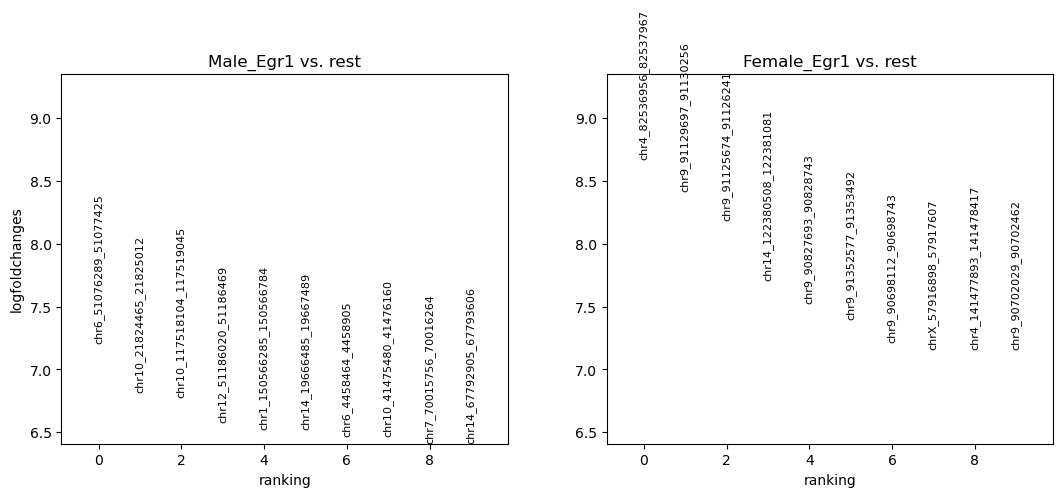

In [14]:
cc.tl.rank_peak_groups(adata_cc, 'Index', method = 'fisher_exact', key_added = 'fisher_exact',
                       rankby = 'logfoldchanges')
cc.pl.rank_peak_groups(adata_cc, key = 'fisher_exact',rankby = 'logfoldchanges')

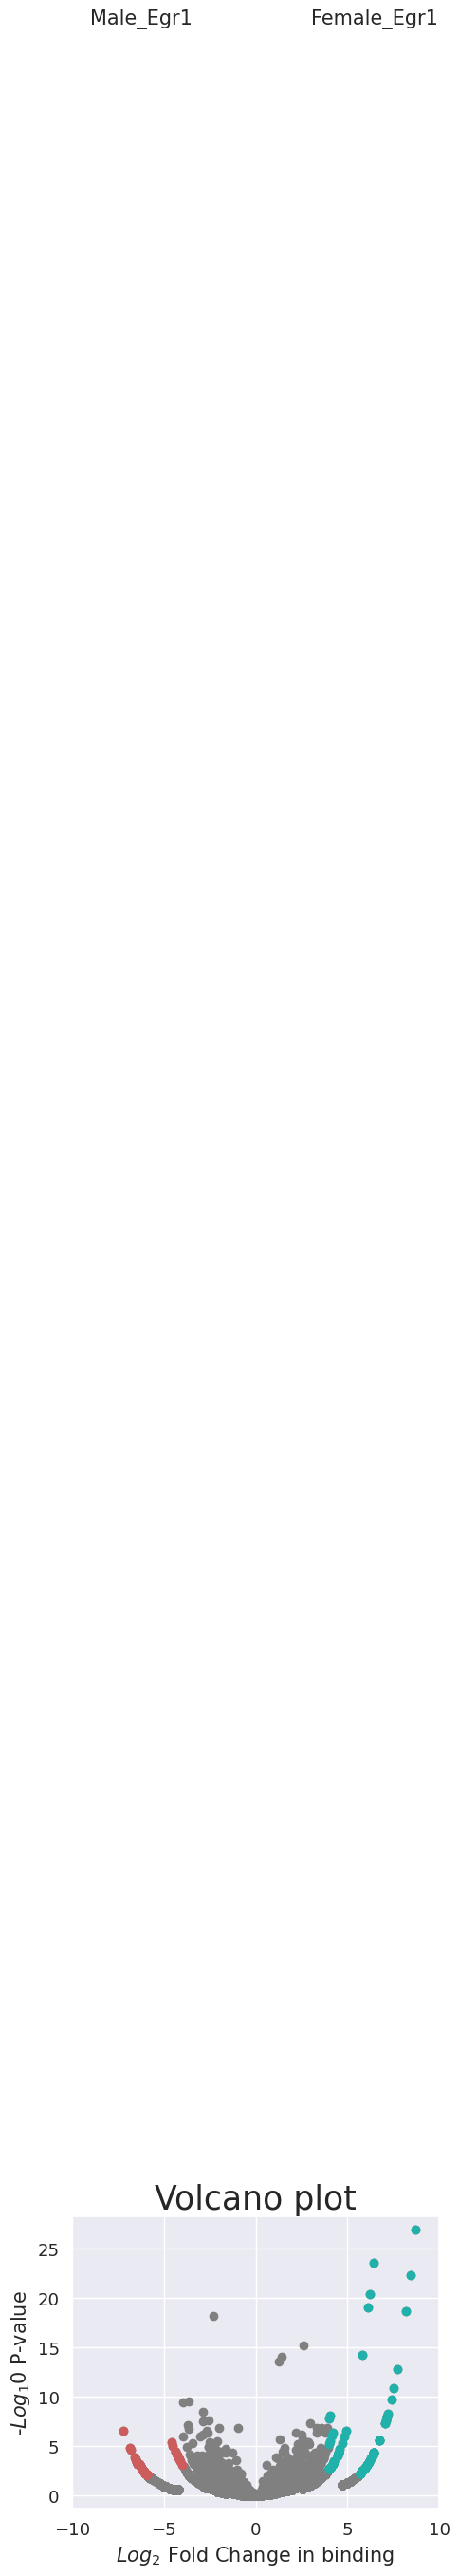

In [15]:
cc.pl.volcano_plot(adata_cc, pvalue_name = 'pvalues_adj', pvalue_cutoff = 0.01, lfc_cutoff = 4,
                   figsize = (5,4), labelright = (3,250), labelleft = (-9,250))

In [16]:
from pycallingcards.tools import rank_peak_groups_df

df = rank_peak_groups_df(
    adata_cc,
    key='fisher_exact',       # ← must match key_added above
    group=None,               # or a specific group like group='GroupA'
    pval_cutoff=0.05,         # optional
    logfc_min=0.5             # optional
)
#df.to_csv("Male_vs_Female_Egr1CC_peaks_calledTogether_091725.txt", sep="\t", index=False, header = True)

     Chr      Start        End  logfoldchanges       pvalues   pvalues_adj  \
0   chr6   51076289   51077425        7.209099  5.392219e-10  2.738141e-07   
1  chr10   21824465   21825012        6.819825  5.813617e-08  1.476062e-05   
2  chr10  117518104  117519045        6.774433  1.011433e-07  2.356521e-05   
3  chr12   51186020   51186469        6.577076  1.015486e-06  1.436478e-04   
4   chr1  150566285  150566784        6.523209  1.861283e-06  2.347825e-04   

   number  number_rest   total  total_rest      group  
0      42            0  285785      196715  Male_Egr1  
1      32            0  285785      196715  Male_Egr1  
2      31            0  285785      196715  Male_Egr1  
3      27            0  285785      196715  Male_Egr1  
4      26            0  285785      196715  Male_Egr1  
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


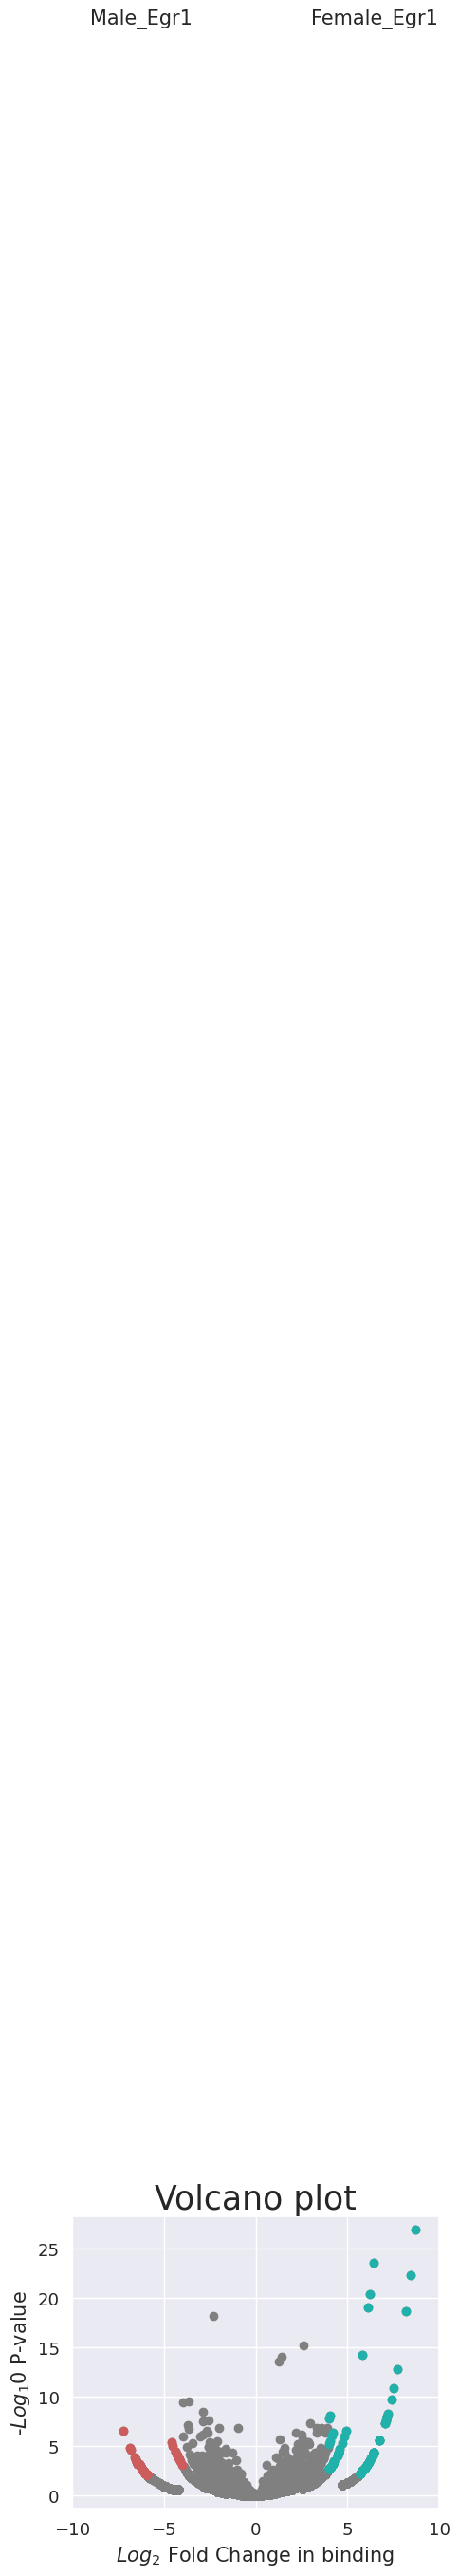

In [17]:
import pybedtools
from pycallingcards.tools import rank_peak_groups_df

df = rank_peak_groups_df(
    adata_cc,
    key='fisher_exact',       # ← must match key_added above
    group=None,               # or a specific group like group='GroupA'
    pval_cutoff=0.05,         # optional
    logfc_min=0.5             # optional
)
df
# Split the 'names' column into Chromosome, Start, and End
df[['Chr', 'Start', 'End']] = df['names'].str.split('_', expand=True)

# Optionally, reorder columns
df = df[['Chr', 'Start', 'End'] + [col for col in df.columns if col not in ['names', 'Chr', 'Start', 'End']]]

# View updated DataFrame
print(df.head())
# Save to temporary file
df.to_csv("MvsF_fisher_calledTogether_p05_TTAAp001_091725.bed", sep="\t", header=False, index=False)

# Sort it using bedtools (matches reference order)
df_bed = pybedtools.BedTool("MvsF_fisher_calledTogether_p05_TTAAp001_091725.bed").sort()

# Pass sorted BEDTool directly
df_annotation = cc.pp.annotation(peaks_path=df_bed.fn, reference="mm10")
df_annotation

# Create a unique peak identifier to match both DataFrames
df['peak_id'] = df['Chr'].astype(str) + "_" + df['Start'].astype(str) + "_" + df['End'].astype(str)
df_annotation['peak_id'] = df_annotation['Chr'].astype(str) + "_" + df_annotation['Start'].astype(str) + "_" + df_annotation['End'].astype(str)

# Create a mapping from peak_id to sort order based on df_annotation
sort_order = {peak: i for i, peak in enumerate(df_annotation['peak_id'])}

# Add sort order to df
df['sort_order'] = df['peak_id'].map(sort_order)

# Drop unmatched peaks if any, then sort
df_sorted = df.dropna(subset=['sort_order']).sort_values(by='sort_order').drop(columns=['sort_order', 'peak_id'])

# Optional: reset index
df_sorted = df_sorted.reset_index(drop=True)

for col in ['Chr', 'Start', 'End']:
    df_sorted[col] = df_sorted[col].astype(str)
    df_annotation[col] = df_annotation[col].astype(str)
# Now you can safely combine them

df_annotation_combined = cc.pp.combine_annotation(df_sorted, df_annotation)
df_annotation_combined.to_csv("Male_vs_Female_Egr1CC_peaks_calledTogether_Fishers_annotated_p05_TTAAp001_091725.txt", sep="\t", index=False, header = True)
cc.pl.volcano_plot(adata_cc, pvalue_name = 'pvalues_adj', pvalue_cutoff = 0.01, lfc_cutoff = 4,
                   figsize = (5,4), labelright = (3,250), labelleft = (-9,250))

In [19]:
# Subset the dataframe by group == "Female_Egr1"
male_egr1_df = df_annotation_combined[df_annotation_combined["group"] == "Male_Egr1"]
female_egr1_df = df_annotation_combined[df_annotation_combined["group"] == "Female_Egr1"]
female_egr1_df

,Chr,Start,End,logfoldchanges,pvalues,pvalues_adj,number,number_rest,total,total_rest,group,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2,peak_id
0,chr1,4858460,4859513,0.874490,0.001389,0.026747,62,49,196715,285785,Female_Egr1,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726,chr1_4858460_4859513
1,chr1,4859557,4860097,3.784595,0.000171,0.006896,12,1,196715,285785,Female_Egr1,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823,chr1_4859557_4860097
2,chr1,6274010,6274413,4.723421,0.011264,0.088426,5,0,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918,chr1_6274010_6274413
3,chr1,6282928,6283331,1.049130,0.022832,0.131957,23,16,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,-6825,NM_001195732,Alkal1,+,76000,chr1_6282928_6283331
4,chr1,6305286,6306216,1.056355,0.005734,0.060886,36,25,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,-29183,NM_001195732,Alkal1,+,53115,chr1_6305286_6306216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,chrX,166972767,166973170,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_001101606,Gm8817,-,90279,NM_021278,Tmsb4x,-,233924,chrX_166972767_166973170
4935,chrX,169095314,169095969,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_009707,Arhgap6,+,0,NM_001287530,Arhgap6,+,16909,chrX_169095314_169095969
4936,chrX,169112705,169113108,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_009707,Arhgap6,+,0,NM_001081978,Amelx,-,63006,chrX_169112705_169113108
4937,chrX,169861134,169861537,2.381179,0.019334,0.123562,8,2,196715,285785,Female_Egr1,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082,chrX_169861134_169861537


In [20]:
peak_annotation_Male = male_egr1_df
peak_annotation_Female = female_egr1_df

# Compare to the guide 3 as above

In [21]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MvF_MaleBiased_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MvF_FemaleBiased_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes: 579
Female genes: 720
Number of overlapping genes: 74
['Pdgfb', 'Jam2', 'Gng2', 'Kazald1', 'Nfatc2']
Number of WHaoverlapping genes: 98
['Polr3g', 'Tgfb1', 'Synpo', 'Stox2', 'Sesn3']


# Conclusion: Calling peaks together gets rid of a lot of genes, so let's not use the combined peaks.

# Now, finish heatmaps for the old and new peaks (090925) and determine if I should keep the original one, or change it to the more strict p values (the new analysis).

# Heatmaps look the same, so just keep the original one.
# Let's run motif enrichment analysis on the sex-specific peaks.

#### A) Combine M and F peaks, and plot top motifs that are sex-specific¶

In [18]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [19]:
import pybedtools
peak = cc.rd.combine_qbed([peak_data_Male, peak_data_Female])
peak = pybedtools.BedTool.from_dataframe(peak).merge().to_dataframe()
peak_data = peak.rename(columns={"chrom":"Chr", "start":"Start", "end":"End"})
peak_annotation = cc.pp.annotation(peak_data, reference = "mm10")
peak_annotation = cc.pp.combine_annotation(peak_data, peak_annotation)
peak_annotation

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4784900,4785471,NR_033530,Mrpl15,-,0,NM_008866,Lypla1,+,22422
1,chr1,4857269,4857866,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859513,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4859557,4860097,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
4,chr1,4916025,4916592,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
...,...,...,...,...,...,...,...,...,...,...,...
19799,chrY,1010650,1011053,NM_012011,Eif2s3y,+,0,NR_027507,Tspy-ps,-,44711
19800,chrY,4389185,4389754,NM_001166384,Rbmy,+,-605915,NM_001166384,Rbmy,-,-979019
19801,chrY,4390332,4390889,NM_001166384,Rbmy,+,-607062,NM_001166384,Rbmy,-,-980166
19802,chrY,42511500,42512135,NR_038299,Gm20871,+,418188,NR_038299,Gm20871,+,1440037


In [20]:
Egr1 = cc.rd.combine_qbed([Male_Egr1, Female_Egr1])
Egr1

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3042835,3042839,1,+,TCGTG/GCTACATGTG/CTGA,Male_Egr1
1,chr1,3045362,3045366,1,+,TCGTG/GCTACATGTG/ACAC,Male_Egr1
2,chr1,3046027,3046031,2,-,TCGTG/CACAGCGCGT/CTGA,Female_Egr1
3,chr1,3052537,3052541,1,+,TCGTG/ATACTCTAGG/GTCA,Male_Egr1
4,chr1,3055563,3055567,4,+,TCGTG/GTTATCGGAT/TCGA,Female_Egr1
...,...,...,...,...,...,...,...
3266333,chrY_JH584300_random,29071,29075,2,-,TCGTG/ATACTCTAGG/TTGG,Male_Egr1
3266334,chrY_JH584300_random,29071,29075,1,-,TCGTG/GACTTAATAC/CATG,Female_Egr1
3266335,chrY_JH584303_random,14934,14938,1,+,TCGTG/ATACTCTAGG/TCGA,Male_Egr1
3266336,chrY_JH584303_random,35487,35491,1,-,TCGTG/GACTTAATAC/CTGA,Female_Egr1


100%|██████████| 2/2 [01:18<00:00, 39.38s/it]


     Chr      Start        End  logfoldchanges       pvalues   pvalues_adj  \
0   chr4   88955203   88957354        2.288249  2.567309e-22  7.263285e-19   
1   chr2  138362212  138363307        3.664047  2.221598e-13  2.933102e-10   
2  chr10  119169106  119170026        3.960227  3.156316e-13  3.906730e-10   
3  chr11  103264051  103264610        2.873806  2.637162e-12  3.072139e-09   
4  chr16   77479518   77481038        2.575253  3.325982e-11  2.533375e-08   

   number  number_rest   total  total_rest      group  
0     214           30  285785      196715  Male_Egr1  
1      77            4  285785      196715  Male_Egr1  
2      72            3  285785      196715  Male_Egr1  
3      87            8  285785      196715  Male_Egr1  
4      88           10  285785      196715  Male_Egr1  
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


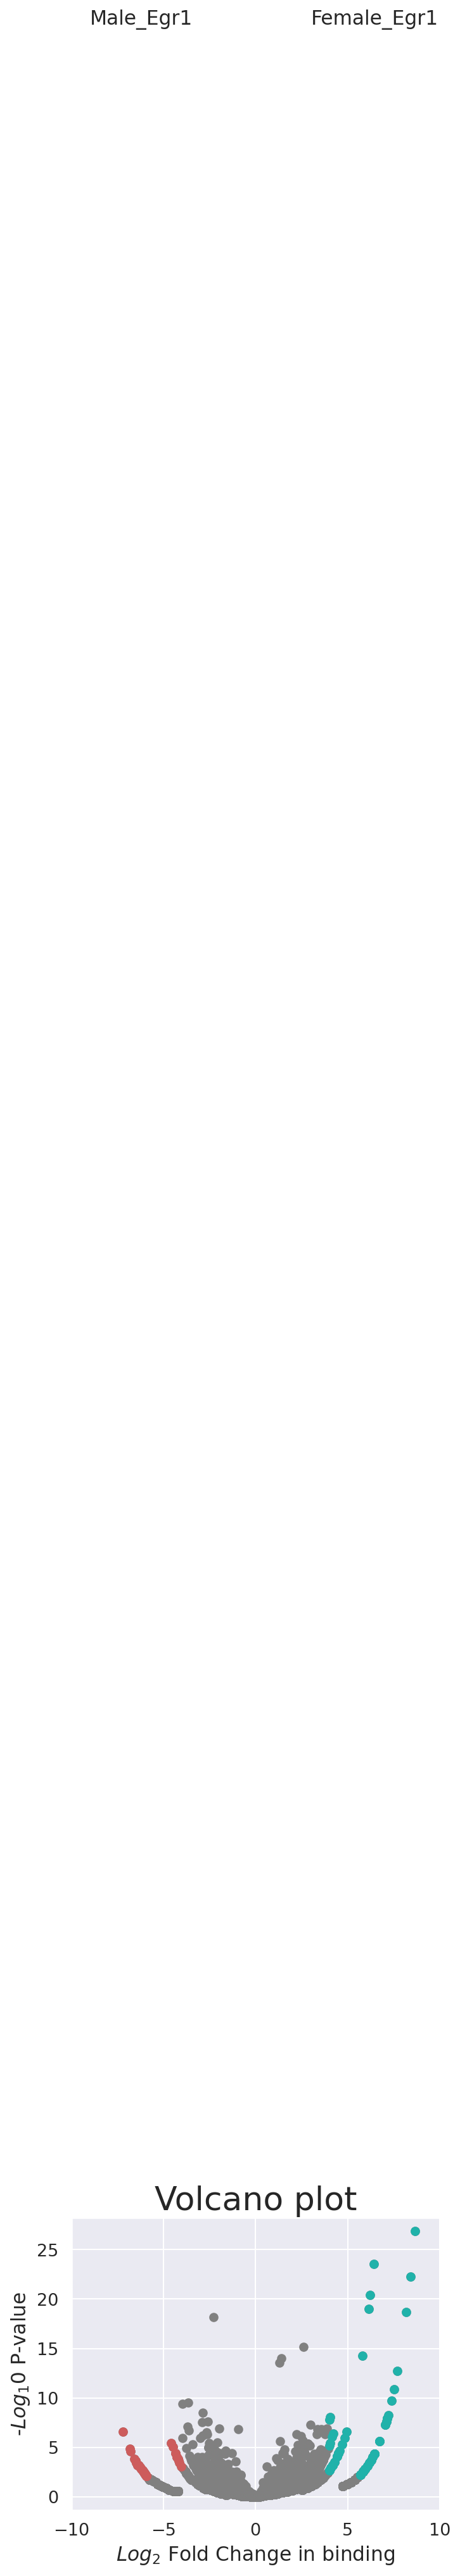

In [21]:
import pybedtools
from pycallingcards.tools import rank_peak_groups_df
cc.tl.rank_peak_groups(adata_cc, 'Index', method = 'fisher_exact', key_added = 'fisher_exact')
df = rank_peak_groups_df(
    adata_cc,
    key='fisher_exact',       # ← must match key_added above
    group=None,               # or a specific group like group='GroupA'
    pval_cutoff=0.05,         # optional
    logfc_min=0.5             # optional
)
df
# Split the 'names' column into Chromosome, Start, and End
df[['Chr', 'Start', 'End']] = df['names'].str.split('_', expand=True)

# Optionally, reorder columns
df = df[['Chr', 'Start', 'End'] + [col for col in df.columns if col not in ['names', 'Chr', 'Start', 'End']]]

# View updated DataFrame
print(df.head())
# Save to temporary file
df.to_csv("MvsF_fisher_calledSeparately_w300_p05_TTAA001.bed", sep="\t", header=False, index=False)

# Sort it using bedtools (matches reference order)
df_bed = pybedtools.BedTool("MvsF_fisher_calledSeparately_w300_p05_TTAA001.bed").sort()

# Pass sorted BEDTool directly
df_annotation = cc.pp.annotation(peaks_path=df_bed.fn, reference="mm10")
df_annotation

# Create a unique peak identifier to match both DataFrames
df['peak_id'] = df['Chr'].astype(str) + "_" + df['Start'].astype(str) + "_" + df['End'].astype(str)
df_annotation['peak_id'] = df_annotation['Chr'].astype(str) + "_" + df_annotation['Start'].astype(str) + "_" + df_annotation['End'].astype(str)

# Create a mapping from peak_id to sort order based on df_annotation
sort_order = {peak: i for i, peak in enumerate(df_annotation['peak_id'])}

# Add sort order to df
df['sort_order'] = df['peak_id'].map(sort_order)

# Drop unmatched peaks if any, then sort
df_sorted = df.dropna(subset=['sort_order']).sort_values(by='sort_order').drop(columns=['sort_order', 'peak_id'])

# Optional: reset index
df_sorted = df_sorted.reset_index(drop=True)

for col in ['Chr', 'Start', 'End']:
    df_sorted[col] = df_sorted[col].astype(str)
    df_annotation[col] = df_annotation[col].astype(str)
# Now you can safely combine them

df_annotation_combined = cc.pp.combine_annotation(df_sorted, df_annotation)
df_annotation_combined.to_csv("MvsF_fisher_calledSeparately_w300_p05_TTAA001_Fishers_annotated.txt", sep="\t", index=False, header = True)
cc.pl.volcano_plot(adata_cc, pvalue_name = 'pvalues_adj', pvalue_cutoff = 0.01, lfc_cutoff = 4,
                   figsize = (5,4), labelright = (3,250), labelleft = (-9,250))

In [15]:
adata_cc.obs

""
Index
Male_Egr1
Female_Egr1


In [16]:
print(df[['group', 'logfoldchanges', 'pvalues_adj']].head())

       group  logfoldchanges   pvalues_adj
0  Male_Egr1        2.288249  7.263285e-19
1  Male_Egr1        3.664047  2.933102e-10
2  Male_Egr1        3.960227  3.906730e-10
3  Male_Egr1        2.873806  3.072139e-09
4  Male_Egr1        2.575253  2.533375e-08


In [24]:
# Select rows where group == "Egr1KD_gRNA2_Female"
male_subset = df_annotation_combined[df_annotation_combined["group"] == "Male_Egr1"]
female_subset = df_annotation_combined[df_annotation_combined["group"] == "Female_Egr1"]
female_subset


,Chr,Start,End,logfoldchanges,pvalues,pvalues_adj,number,number_rest,total,total_rest,group,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2,peak_id
0,chr1,4858460,4859513,0.874490,0.001389,0.026747,62,49,196715,285785,Female_Egr1,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726,chr1_4858460_4859513
1,chr1,4859557,4860097,3.784595,0.000171,0.006896,12,1,196715,285785,Female_Egr1,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823,chr1_4859557_4860097
2,chr1,6274010,6274413,4.723421,0.011264,0.088426,5,0,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918,chr1_6274010_6274413
3,chr1,6282928,6283331,1.049130,0.022832,0.131957,23,16,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,-6825,NM_001195732,Alkal1,+,76000,chr1_6282928_6283331
4,chr1,6305286,6306216,1.056355,0.005734,0.060886,36,25,196715,285785,Female_Egr1,NM_009826,Rb1cc1,+,-29183,NM_001195732,Alkal1,+,53115,chr1_6305286_6306216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,chrX,166972767,166973170,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_001101606,Gm8817,-,90279,NM_021278,Tmsb4x,-,233924,chrX_166972767_166973170
4935,chrX,169095314,169095969,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_009707,Arhgap6,+,0,NM_001287530,Arhgap6,+,16909,chrX_169095314_169095969
4936,chrX,169112705,169113108,2.553774,0.044622,0.189627,5,1,196715,285785,Female_Egr1,NM_009707,Arhgap6,+,0,NM_001081978,Amelx,-,63006,chrX_169112705_169113108
4937,chrX,169861134,169861537,2.381179,0.019334,0.123562,8,2,196715,285785,Female_Egr1,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082,chrX_169861134_169861537


In [25]:
male_subset

,Chr,Start,End,logfoldchanges,pvalues,pvalues_adj,number,number_rest,total,total_rest,group,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2,peak_id
11,chr1,10943202,10943827,2.415776,0.000023,0.001614,40,5,285785,196715,Male_Egr1,NM_029525,Prex2,+,49638,NR_030645,Mir467e,-,-77329,chr1_10943202_10943827
21,chr1,17164489,17164994,4.857636,0.024781,0.134885,8,0,285785,196715,Male_Egr1,NM_010267,Gdap1,+,-220,NM_020604,Jph1,-,-66601,chr1_17164489_17164994
22,chr1,17451239,17451642,4.857636,0.024781,0.134885,8,0,285785,196715,Male_Egr1,NM_053191,Pi15,+,150259,NR_130314,Gm16070,-,224385,chr1_17451239_17451642
23,chr1,17600399,17600802,5.022022,0.013351,0.096282,9,0,285785,196715,Male_Egr1,NM_053191,Pi15,+,1099,NR_130314,Gm16070,-,75225,chr1_17600399_17600802
24,chr1,17601256,17601765,4.672082,0.046485,0.189627,7,0,285785,196715,Male_Egr1,NM_053191,Pi15,+,136,NR_130314,Gm16070,-,74262,chr1_17601256_17601765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4930,chrX,164379844,164380485,3.544494,0.000463,0.013338,20,1,285785,196715,Male_Egr1,NM_010216,Vegfd,+,0,NM_027153,Pir,+,-6832,chrX_164379844_164380485
4932,chrX,167091544,167092043,1.993956,0.003517,0.048399,24,4,285785,196715,Male_Egr1,NM_001101606,Gm8817,-,-21175,NM_021278,Tmsb4x,-,115051,chrX_167091544_167092043
4933,chrX,167209494,167210372,1.240056,0.004622,0.053308,45,13,285785,196715,Male_Egr1,NM_021278,Tmsb4x,-,-277,NM_001313760,Tlr8,-,30751,chrX_167209494_167210372
4934,chrX,167319256,167319772,2.933909,0.011616,0.089338,13,1,285785,196715,Male_Egr1,NM_133211,Tlr7,-,0,NM_001313758,Prps2,-,26548,chrX_167319256_167319772


# VENN DIAGRAMS AS BEFORE:
## code from: Goal: Make Figure 5 for Egr1 paper: Egr1 binds differently in Males and Females.ipynb jupyterlab notebook.

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


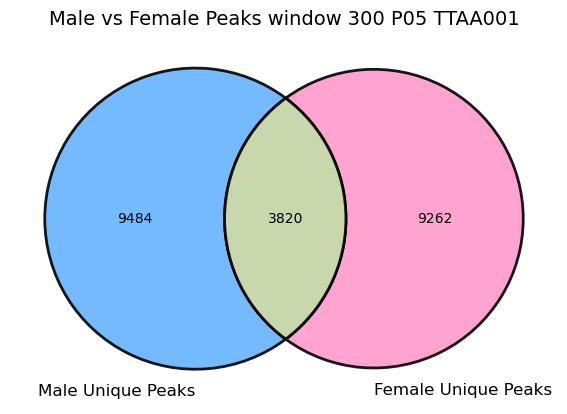

In [26]:
import pandas as pd
import pyranges as pr

# Rename column names to match PyRanges requirements
peak_data_Male.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Male_gr = pr.PyRanges(peak_data_Male)

# Rename column names to match PyRanges requirements
peak_data_Female.rename(columns={"Chr": "Chromosome"}, inplace=True)
# Convert to PyRanges object
peak_data_Female_gr = pr.PyRanges(peak_data_Female)

# Find overlaps
common = peak_data_Male_gr.intersect(peak_data_Female_gr)
common

# Convert your PyRanges object to DataFrame
common_df = common.df
# Make sure it has the correct columns in the right order
common_df = common_df[['Chromosome', 'Start', 'End']]  # rename if necessary
common_df.columns = ['chrom', 'start', 'end']
# Save to temporary file
common_df.to_csv("common_peaks_unsorted.bed", sep="\t", header=False, index=False)
# Sort it using bedtools (matches reference order)
sorted_common_bed = pybedtools.BedTool("common_peaks_unsorted.bed").sort()
# Pass sorted BEDTool directly
peak_annotation_common = cc.pp.annotation(peaks_path=sorted_common_bed.fn, reference="mm10")

#peak_annotation_common.to_csv("shared_peaks_malefemale_calledSeparately_annotated.txt", sep="\t", index=False, header=True)
peak_annotation_common.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_annotated_091725.txt", sep="\t", index=False, header=True)

unique_peaks1 = peak_data_Male_gr.subtract(peak_data_Female_gr)
unique_peaks1
unique_peaks2 = peak_data_Female_gr.subtract(peak_data_Male_gr)
unique_peaks2

import pyranges as pr
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Assuming peaks1 and peaks2 are PyRanges objects
# For example:
# peaks1 = pr.read("male_peaks.bed")
# peaks2 = pr.read("female_peaks.bed")

# Count the number of intervals
size_common = len(common)
size_unique_peaks1 = len(unique_peaks1)
size_unique_peaks2 = len(unique_peaks2)

# Save the unique peaks as text or CSV files
unique_peaks1_df = unique_peaks1.df  # Convert PyRanges object to a DataFrame
unique_peaks2_df = unique_peaks2.df  # Convert PyRanges object to a DataFrame
common_df = common.df # Convert PyRanges object to a DataFrame

# Save as text files (you can change this to CSV if needed)
unique_peaks1_df.to_csv("unique_peaks_male_calledSeparately_W300_P05_TTAA001_annotated_091725.txt", sep="\t", index=False)
unique_peaks2_df.to_csv("unique_peaks_female_calledSeparately_W300_P05_TTAA001_annotated_091725.txt", sep="\t", index=False)
common_df.to_csv("shared_peaks_malefemale_calledSeparately_W300_P05_TTAA001_annotated_091725.txt", sep="\t", index=False)

# Create figure
plt.figure(figsize=(6, 6))
# Create the Venn diagram
venn = venn2(
    subsets=(size_unique_peaks1, size_unique_peaks2, size_common),
    set_labels=('Male Unique Peaks', 'Female Unique Peaks')
)
colors = {
    '10': '#66b3ff',  # light blue
    '01': '#ff99cc',  # light pink
    '11': '#c3d3a3'   # neutral gray for the intersection
}
# Style each section
for subset_id in ['10', '01', '11']:
    patch = venn.get_patch_by_id(subset_id)
    if patch:
        patch.set_color(colors[subset_id])
        patch.set_edgecolor('black')
        patch.set_linewidth(2)
        patch.set_alpha(0.9)  # make slightly more opaque for punchier colors

# Add title and show plot
plt.title('Male vs Female Peaks window 300 P05 TTAA001', fontsize=14)
plt.tight_layout()
plt.savefig('Male_vs_Female_W300_P05_TTAA001_annotated_091725_PeakIntersection.jpeg', format='jpeg', dpi=300)
plt.show()

In [27]:
unique_peaks1_df

,Chromosome,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4784900,4785471,4785220.0,31,17,6,0.000000e+00,1.620815e-02,0.000015,1484.596829,8.910119e-06,891.011943,593.584886,0.000000e+00
1,chr1,4859024,4859513,4858781.0,49,21,11,0.000000e+00,1.886541e-05,0.000023,2346.620794,1.100662e-05,1100.661812,1245.958982,0.000000e+00
2,chr1,4916025,4916592,4916389.0,9,3,5,1.477386e-10,1.421251e-02,0.000004,431.011983,1.572374e-06,157.237402,273.774581,1.198626e-07
3,chr1,6281371,6281961,6281636.0,7,3,4,1.062140e-06,3.880421e-02,0.000003,335.231542,1.572374e-06,157.237402,177.994140,5.138162e-04
4,chr1,6305876,6306216,6305959.0,12,6,5,1.394584e-11,2.244018e-02,0.000006,574.682643,3.144748e-06,314.474803,260.207840,1.262629e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9479,chrY,1010650,1011053,1010850.0,6,0,4,1.737513e-08,1.818001e-11,0.000003,287.341322,0.000000e+00,0.000000,287.341322,1.087454e-05
9480,chrY,4389185,4389754,4389516.0,5,4,17,4.358508e-08,4.730544e-02,0.000002,239.451101,2.096499e-06,209.649869,29.801232,2.588767e-05
9481,chrY,4390332,4390889,4390554.0,5,1,15,3.170588e-08,1.040715e-04,0.000002,239.451101,5.241247e-07,52.412467,187.038634,1.917295e-05
9482,chrY,42511500,42512135,42511800.5,6,1,9,8.117140e-11,2.004553e-05,0.000003,287.341322,5.241247e-07,52.412467,234.928854,6.789101e-08


In [28]:
unique_peaks2_df

,Chromosome,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,2.070923e-02,0.000010,1018.477732,0.000005,533.555292,484.922440,4.743755e-11
1,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,4.037573e-02,0.000004,424.365722,0.000003,333.472058,90.893664,1.695793e-04
2,chr1,6282928,6283331,6283128.0,23,33,3,0.000000e+00,3.177280e-02,0.000020,1952.082320,0.000022,2200.915581,-248.833261,0.000000e+00
3,chr1,6305286,6305705,6305637.0,31,37,11,0.000000e+00,1.321674e-03,0.000026,2631.067475,0.000025,2467.693227,163.374248,0.000000e+00
4,chr1,6312492,6312969,6312766.0,12,16,2,9.992007e-16,4.983013e-02,0.000010,1018.477732,0.000011,1067.110585,-48.632852,1.394558e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9257,chrX,169396222,169396672,169396422.0,5,0,2,5.296706e-08,1.274899e-09,0.000004,424.365722,0.000000,0.000000,424.365722,3.165906e-05
9258,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,7.184145e-04,0.000007,678.985155,0.000003,266.777646,412.207509,2.482385e-07
9259,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,3.298981e-02,0.000008,848.731444,0.000007,666.944115,181.787328,1.377614e-07
9260,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,2.384857e-02,0.000010,1018.477732,0.000008,800.332939,218.144794,5.157978e-10


In [29]:
common_df

,Chromosome,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4857269,4857866,4857663.0,42,20,4,0.000000e+00,0.000463,0.000020,2011.389252,1.048249e-05,1048.249345,963.139907,0.000000e+00
1,chr1,4858460,4859024,4858781.0,49,21,11,0.000000e+00,0.000019,0.000023,2346.620794,1.100662e-05,1100.661812,1245.958982,0.000000e+00
2,chr1,6215285,6215688,6215485.0,13,5,2,0.000000e+00,0.002387,0.000006,622.572864,2.620623e-06,262.062336,360.510528,0.000000e+00
3,chr1,6286893,6287296,6287093.0,7,2,2,1.565760e-08,0.005862,0.000003,335.231542,1.048249e-06,104.824934,230.406608,9.869091e-06
4,chr1,6305705,6305876,6305959.0,12,6,5,1.394584e-11,0.022440,0.000006,574.682643,3.144748e-06,314.474803,260.207840,1.262629e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3815,chrX,166328810,166329228,166329010.0,15,4,2,0.000000e+00,0.000004,0.000007,718.353304,2.096499e-06,209.649869,508.703435,0.000000e+00
3816,chrX,166478612,166479015,166478812.0,6,2,1,7.406392e-08,0.005183,0.000003,287.341322,1.048249e-06,104.824934,182.516387,4.253285e-05
3817,chrX,166504333,166504736,166504533.0,15,5,2,0.000000e+00,0.000063,0.000007,718.353304,2.620623e-06,262.062336,456.290968,0.000000e+00
3818,chrX,167209969,167210027,167210169.0,6,1,1,2.660443e-08,0.000968,0.000003,287.341322,5.241247e-07,52.412467,234.928854,1.624312e-05


In [30]:
cc.tl.call_motif(peaks_frame = unique_peaks1_df, reference = "mm10", save_homer = "Homer/GBM_Peaks_Egr1_CalledSeparately_MaleUnique_091725",
                 homer_path = "/home/ihreiss/homer/bin/", num_cores=12)

There is no save_name, it will save to temp_Homer_trial.bed and then delete.



	Position file = temp_Homer_trial.bed
	Genome = mm10
	Output Directory = Homer/GBM_Peaks_Egr1_CalledSeparately_MaleUnique_091725
	Fragment size set to 1000
	Using 12 CPUs
	Will not run homer for de novo motifs
	Found mset for "mouse", will check against vertebrates motifs
	Peak/BED file conversion summary:
		BED/Header formatted lines: 9484
		peakfile formatted lines: 0

	Peak File Statistics:
		Total Peaks: 9484
		Redundant Peak IDs: 0
		Peaks lacking information: 0 (need at least 5 columns per peak)
		Peaks with misformatted coordinates: 0 (should be integer)
		Peaks with misformatted strand: 0 (should be either +/- or 0/1)

	Peak file looks good!

	Background files for 1000 bp fragments found.
	Custom genome sequence directory: /home/ihreiss/homer//data/genomes/mm10//

	Extracting sequences from directory: /home/ihreiss/homer//data/genomes/mm10//
	Extracting 692 sequences from chr1
	Extracting 699 sequences from chr2
	Extracting 600 sequences from chr3
	Extracting 497 sequences fro

Finished!


		153 of 440 (1e-3) STAT1(Stat)/HelaS3-STAT1-ChIP-Seq(GSE12782)/Homer
		154 of 440 (1e-3) RFX(HTH)/K562-RFX3-ChIP-Seq(SRA012198)/Homer
		155 of 440 (1e-3) ELF5(ETS)/T47D-ELF5-ChIP-Seq(GSE30407)/Homer
		156 of 440 (1e-3) HIC1(Zf)/Treg-ZBTB29-ChIP-Seq(GSE99889)/Homer
		157 of 440 (1e-3) CArG(MADS)/PUER-Srf-ChIP-Seq(Sullivan_et_al.)/Homer
		158 of 440 (1e-3) EHF(ETS)/LoVo-EHF-ChIP-Seq(GSE49402)/Homer
		159 of 440 (1e-3) AP-2gamma(AP2)/MCF7-TFAP2C-ChIP-Seq(GSE21234)/Homer
		160 of 440 (1e-3) Foxh1(Forkhead)/hESC-FOXH1-ChIP-Seq(GSE29422)/Homer
		161 of 440 (1e-3) Foxo3(Forkhead)/U2OS-Foxo3-ChIP-Seq(E-MTAB-2701)/Homer
		162 of 440 (1e-3) Zfp809(Zf)/ES-Zfp809-ChIP-Seq(GSE70799)/Homer
		163 of 440 (1e-3) CRX(Homeobox)/Retina-Crx-ChIP-Seq(GSE20012)/Homer
		164 of 440 (1e-3) p53(p53)/Saos-p53-ChIP-Seq(GSE15780)/Homer
		165 of 440 (1e-3) p53(p53)/Saos-p53-ChIP-Seq/Homer
		166 of 440 (1e-3) EBF1(EBF)/Near-E2A-ChIP-Seq(GSE21512)/Homer
		167 of 440 (1e-3) ELF3(ETS)/PDAC-ELF3-ChIP-Seq(GSE64557)/Homer

In [31]:
cc.tl.call_motif(peaks_frame = unique_peaks2_df, reference = "mm10", save_homer = "Homer/GBM_Peaks_Egr1_CalledSeparately_FemaleUnique_091725",
                 homer_path = "/home/ihreiss/homer/bin/", num_cores=12)

There is no save_name, it will save to temp_Homer_trial.bed and then delete.



	Position file = temp_Homer_trial.bed
	Genome = mm10
	Output Directory = Homer/GBM_Peaks_Egr1_CalledSeparately_FemaleUnique_091725
	Fragment size set to 1000
	Using 12 CPUs
	Will not run homer for de novo motifs
	Found mset for "mouse", will check against vertebrates motifs
	Peak/BED file conversion summary:
		BED/Header formatted lines: 9262
		peakfile formatted lines: 0

	Peak File Statistics:
		Total Peaks: 9262
		Redundant Peak IDs: 0
		Peaks lacking information: 0 (need at least 5 columns per peak)
		Peaks with misformatted coordinates: 0 (should be integer)
		Peaks with misformatted strand: 0 (should be either +/- or 0/1)

	Peak file looks good!

	Background files for 1000 bp fragments found.
	Custom genome sequence directory: /home/ihreiss/homer//data/genomes/mm10//

	Extracting sequences from directory: /home/ihreiss/homer//data/genomes/mm10//
	Extracting 642 sequences from chr1
	Extracting 869 sequences from chr2
	Extracting 521 sequences from chr3
	Extracting 572 sequences f

Finished!


		190 of 440 (1e-2) ZNF7(Zf)/HepG2-ZNF7.Flag-ChIP-Seq(Encode)/Homer
		191 of 440 (1e-2) E2F7(E2F)/Hela-E2F7-ChIP-Seq(GSE32673)/Homer
		192 of 440 (1e-2) PBX1(Homeobox)/MCF7-PBX1-ChIP-Seq(GSE28007)/Homer
		193 of 440 (1e-2) X-box(HTH)/NPC-H3K4me1-ChIP-Seq(GSE16256)/Homer
		194 of 440 (1e-2) Sox21(HMG)/ESC-SOX21-ChIP-Seq(GSE110505)/Homer
		195 of 440 (1e-2) MYNN(Zf)/HEK293-MYNN.eGFP-ChIP-Seq(Encode)/Homer
		196 of 440 (1e-2) HIC1(Zf)/Treg-ZBTB29-ChIP-Seq(GSE99889)/Homer
		197 of 440 (1e-2) MyoD(bHLH)/Myotube-MyoD-ChIP-Seq(GSE21614)/Homer
		198 of 440 (1e-2) Bapx1(Homeobox)/VertebralCol-Bapx1-ChIP-Seq(GSE36672)/Homer
		199 of 440 (1e-2) Znf263(Zf)/K562-Znf263-ChIP-Seq(GSE31477)/Homer
		200 of 440 (1e-2) Usf2(bHLH)/C2C12-Usf2-ChIP-Seq(GSE36030)/Homer
		201 of 440 (1e-2) Six1(Homeobox)/Myoblast-Six1-ChIP-Chip(GSE20150)/Homer
		202 of 440 (1e-2) Hoxc9(Homeobox)/Ainv15-Hoxc9-ChIP-Seq(GSE21812)/Homer
		203 of 440 (1e-2) HNF1b(Homeobox)/PDAC-HNF1B-ChIP-Seq(GSE64557)/Homer
		204 of 440 (1e-2) CR

In [32]:
cc.tl.call_motif(peaks_frame = common_df, reference = "mm10", save_homer = "Homer/GBM_Peaks_Egr1_CalledSeparately_SharedMandF_091725",
                 homer_path = "/home/ihreiss/homer/bin/", num_cores=12)


	Position file = temp_Homer_trial.bed
	Genome = mm10
	Output Directory = Homer/GBM_Peaks_Egr1_CalledSeparately_SharedMandF_091725
	Fragment size set to 1000
	Using 12 CPUs
	Will not run homer for de novo motifs
	Found mset for "mouse", will check against vertebrates motifs


There is no save_name, it will save to temp_Homer_trial.bed and then delete.


	Peak/BED file conversion summary:
		BED/Header formatted lines: 3820
		peakfile formatted lines: 0

	Peak File Statistics:
		Total Peaks: 3820
		Redundant Peak IDs: 0
		Peaks lacking information: 0 (need at least 5 columns per peak)
		Peaks with misformatted coordinates: 0 (should be integer)
		Peaks with misformatted strand: 0 (should be either +/- or 0/1)

	Peak file looks good!

	Background files for 1000 bp fragments found.
	Custom genome sequence directory: /home/ihreiss/homer//data/genomes/mm10//

	Extracting sequences from directory: /home/ihreiss/homer//data/genomes/mm10//
	Extracting 234 sequences from chr1
	Extracting 300 sequences from chr2
	Extracting 252 sequences from chr3
	Extracting 232 sequences from chr4
	Extracting 223 sequences from chr5
	Extracting 183 sequences from chr6
	Extracting 207 sequences from chr7
	Extracting 174 sequences from chr8
	Extracting 210 sequences from chr9
	Extracting 207 sequences from chr10
	Extracting 225 sequences from chr11
	Extracting 1

Finished!


	Skipping...
	Job finished - if results look good, please send beer to ..

	Cleaning up tmp files...



# 091925 - Meeting with Rob + Josh 

## do overlap with intersection + union of gRNA2 and gRNA3 DE lists.

In [5]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
# Keep only peaks whose nearest gene is within 20kb
peak_annotation_Male_20000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Male_100000 = peak_annotation_Male[peak_annotation_Male['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Male_20000.to_csv("Male_Egr1CC_peaks_20kbThreshhold_091125.txt", sep="\t", index=False, header=True)
#peak_annotation_Male_100000.to_csv("Male_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
peak_annotation_Female_20000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 20000].reset_index(drop=True)
#peak_annotation_Female_100000 = peak_annotation_Female[peak_annotation_Female['Distance1'].abs() <= 100000].reset_index(drop=True)
peak_annotation_Female_20000.to_csv("Female_Egr1CC_peaks_20kbThreshhold_091125.txt", sep="\t", index=False, header=True)
#peak_annotation_Female_100000.to_csv("Female_Egr1CC_peaks_100kbThreshhold_090825.txt", sep="\t", index=False, header=True)



In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


# Compare to gRNA3 data

In [ ]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg3_vs_Male_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg3_vs_Female_NoTreatg1_DE_vst_filtered_091625.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))


set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Egr1g3vsNeg1.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of WHaoverlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

In [ ]:
______________________________________________________________________________________________________________________________________________

In [14]:
unique_genes_male = pd.concat([
    peak_annotation_Male_100000['Gene Name1']
]).dropna().unique()

print(len(unique_genes_male))


6328


In [15]:
unique_genes_female = pd.concat([
    peak_annotation_Female_20000['Gene Name1']
]).dropna().unique()

print(len(unique_genes_female))


5833


In [16]:
unique_genes_female = pd.concat([
    peak_annotation_Female_100000['Gene Name1']
]).dropna().unique()

print(len(unique_genes_female))


6377


In [17]:
import pandas as pd

# Assuming your table is loaded as a DataFrame called df
# Example: df = pd.read_csv("your_file.tsv", sep="\t")

# Get min and max for Distance1 and Distance2
min_dist1 = peak_annotation_Male_100000["Distance1"].min()
max_dist1 = peak_annotation_Male_100000["Distance1"].max()

min_dist2 = peak_annotation_Male_100000["Distance2"].min()
max_dist2 = peak_annotation_Male_100000["Distance2"].max()

print(f"Distance1 -> min: {min_dist1}, max: {max_dist1}")
print(f"Distance2 -> min: {min_dist2}, max: {max_dist2}")



Distance1 -> min: -99518, max: 99905
Distance2 -> min: -1931292, max: 2412546


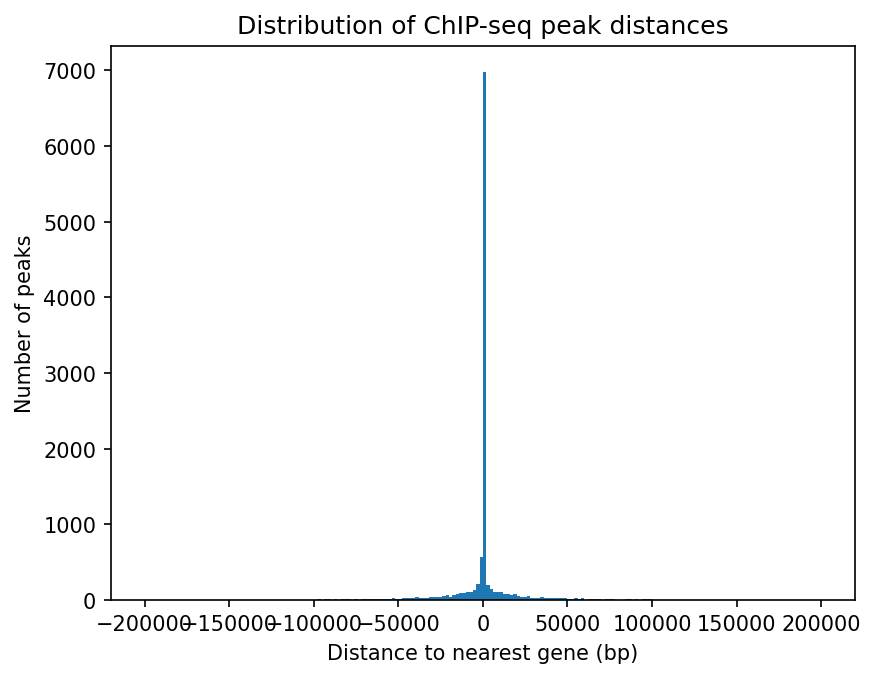

In [18]:
import matplotlib.pyplot as plt

plt.hist(peak_annotation_Male_100000["Distance1"], bins=200, range=(-200000, 200000))  # zoom into ±200 kb
plt.xlabel("Distance to nearest gene (bp)")
plt.ylabel("Number of peaks")
plt.title("Distribution of ChIP-seq peak distances")
plt.show()


In [19]:
import pandas as pd

# Assuming your annotated peaks are in a DataFrame called df
# Example: df = pd.read_csv("your_annotated_peaks.tsv", sep="\t")

# Count how many are > 10kb from the nearest gene
count_over_10kb = (peak_annotation_Male["Distance1"].abs() > 5000).sum()

# Optionally calculate the fraction
fraction_over_10kb = count_over_10kb / len(peak_annotation_Male)

print(f"Number of peaks >10kb from nearest gene: {count_over_10kb}")
print(f"Fraction of total peaks: {fraction_over_10kb:.2%}")


Number of peaks >10kb from nearest gene: 3876
Fraction of total peaks: 32.36%


In [ ]:
# Visuazize peaks if needed:
qbed = {"Male_Egr1": Male_Egr1, "Male_WT": Male_WT, "Female_Egr1": Female_Egr1, "Female_WT": Female_WT}
bed = {"peak_Male": peak_data_Male, "peak_Female": peak_data_Female}
cc.pl.WashU_browser_url(qbed = qbed, bed = bed, genome = 'mm10')

# 2) Import DE comparisons with Neg1 and also with Neg2.
#### To run this step, I have already found common genes that are DE between Egr1 G2 vs Neg1, and Egr1 G3 vs Neg1, and the same vs Neg2, in both males and females. So since the gene list that come out from these comparisons is the same in both txt files comparing each Egr1 guide to the same Neg control, I'm only importing the Egr1 gRNA2 files.

In [20]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] < 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

KD_M_2 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg2_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_2 = KD_M_2[(KD_M_2['log2FoldChange'].abs() >= 0.5) & (KD_M_2['pvalue'] < 0.05)]
print("Male genes G2 vs Neg2:", len(KD_M_2))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] < 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))

KD_F_2 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg2_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_2 = KD_F_2[(KD_F_2['log2FoldChange'].abs() >= 0.5) & (KD_F_2['pvalue'] < 0.05)]
print("Female genes G2 vs Neg2:", len(KD_F_2))

Male genes G2 vs Neg1: 268
Male genes G2 vs Neg2: 24
Female genes G2 vs Neg1: 341
Female genes G2 vs Neg2: 78


## Based on previous analyses, I will keep going only with Neg1.

In [21]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))


Male genes G2 vs Neg1: 268
Female genes G2 vs Neg1: 341


#### Get overlap lists for Egr1 CC 1st and 2nd nearest genes identified in 1) above, and overlap with DE comparisons with Neg1 control.

In [64]:
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Neg1_090825.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Number of overlapping genes: 119
['Bmp4', 'Ccbe1', 'Col2a1', 'Ccdc88b', 'Hmox1']


In [65]:
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Neg1_090825.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Number of overlapping genes: 134
['Slit3', 'Mpv17l', 'Ets2', 'Fam180a', 'Acss1']


In [66]:
"Egr2" in overlap_genes1


True

#### Make Venn Diagrams

In [67]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 20kb NearestGene'
set2_name = 'Male_Egr1KD Neg1_090825'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 119
['Bmp4', 'Ccbe1', 'Col2a1', 'Ccdc88b', 'Hmox1']
Percent of overlapping genes: 44.91


In [68]:
# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 20kb NearestGene'
set2_name = 'Female_Egr1KD Neg1_90825'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 134
['Slit3', 'Mpv17l', 'Ets2', 'Fam180a', 'Acss1']
Percent of overlapping genes: 39.53


## Running Enrichr in R. Here run Fisher's exact test.

In [69]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))


Male All Genes: 11790
Male genes: 268
Male genes NOT DE: 11522
Female All Genes: 11623
Female genes: 341
Female genes NOT DE: 11282


In [70]:
from scipy.stats import fisher_exact

In [71]:
# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")



Male Fisher's Exact Test p-value: 3.3181e-04
Odds ratio: 1.5490
Contingency table: [[119, 146], [3946, 7499]]


In [73]:
# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Female Fisher's Exact Test p-value: 1.5797e-01
Odds ratio: 1.1269
Contingency table: [[134, 205], [4113, 7091]]


# 090925

### Overlapping CC with Egr1KD rerun with only removing outliers, removing Neg2, combining both Egr1 targeting guides as one sample, and only doing minimal filtering (CPM > 1, in at leat 1 sample).
### Code in Egr1KD_again_ButCombineEgr1KDsamples_only0filteredout_removeOutliers.Rmd

In [24]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))


Male genes G2 vs Neg1: 505
Female genes G2 vs Neg1: 627


In [25]:
#### Get overlap lists for Egr1 CC 1st and 2nd nearest genes identified in 1) above, and overlap with DE comparisons with Neg1 control.

set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Neg1_090925.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Neg1_090925.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Number of overlapping genes: 208
['Arhgef9', 'Fbxo32', 'Hdac11', 'Slc41a2', 'Pcmtd1']
Number of overlapping genes: 242
['Abcb1b', 'Calcoco1', 'Lrp5', 'Dact2', 'Dner']


#### Make Venn Diagrams

In [26]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 20kb NearestGene'
set2_name = 'Male_Egr1KD Neg1_090925'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 20kb NearestGene'
set2_name = 'Female_Egr1KD Neg1_90925'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 208
['Arhgef9', 'Fbxo32', 'Hdac11', 'Slc41a2', 'Pcmtd1']
Percent of overlapping genes: 41.6
Number of overlapping genes: 242
['Abcb1b', 'Calcoco1', 'Lrp5', 'Dact2', 'Dner']
Percent of overlapping genes: 38.72


## Running Enrichr in R. Here run Fisher's exact test.

In [22]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 12865
Male genes: 505
Male genes NOT DE: 12360
Female All Genes: 12865
Female genes: 627
Female genes NOT DE: 12238
Male Fisher's Exact Test p-value: 1.8209e-04
Odds ratio: 1.4022
Contingency table: [[208, 292], [4129, 8128]]
Female Fisher's Exact Test p-value: 6.3921e-02
Odds ratio: 1.1414
Contingency table: [[242, 383], [4323, 7809]]


# Run it again but without removing outliers

In [27]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun2.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun2.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))
#### Get overlap lists for Egr1 CC 1st and 2nd nearest genes identified in 1) above, and overlap with DE comparisons with Neg1 control.

set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Neg1_090925_2.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Neg1_090925_2.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes G2 vs Neg1: 529
Female genes G2 vs Neg1: 730
Number of overlapping genes: 215
['Arhgef9', 'Cftr', 'Myo6', 'Fbxo32', 'Sprr3']
Number of overlapping genes: 264
['Abcb1b', 'Fbxo32', 'Calcoco1', 'Spink2', 'Lrp5']


#### Make Venn Diagrams

In [28]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 20kb NearestGene'
set2_name = 'Male_Egr1KD Neg1_090925_2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 20kb NearestGene'
set2_name = 'Female_Egr1KD Neg1_90925_2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 215
['Arhgef9', 'Cftr', 'Myo6', 'Fbxo32', 'Sprr3']
Percent of overlapping genes: 40.95
Number of overlapping genes: 264
['Abcb1b', 'Fbxo32', 'Calcoco1', 'Spink2', 'Lrp5']
Percent of overlapping genes: 36.36


## Running Enrichr in R. Here run Fisher's exact test.

In [29]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun2.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun2.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 13039
Male genes: 529
Male genes NOT DE: 12510
Female All Genes: 13039
Female genes: 730
Female genes NOT DE: 12309
Male Fisher's Exact Test p-value: 2.2407e-04
Odds ratio: 1.3853
Contingency table: [[215, 310], [4137, 8263]]
Female Fisher's Exact Test p-value: 3.1456e-01
Odds ratio: 1.0422
Contingency table: [[264, 462], [4320, 7879]]


# FINAL TRY

# Run it again but WITH removing outliers and filtering lowly expressed genes

In [30]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))
#### Get overlap lists for Egr1 CC 1st and 2nd nearest genes identified in 1) above, and overlap with DE comparisons with Neg1 control.

set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_20kb_NearestGene_vs_Neg1_090925_3.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_20kb_NearestGene_vs_Neg1_090925_3.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Male genes G2 vs Neg1: 487
Female genes G2 vs Neg1: 610
Number of overlapping genes: 203
['Arhgef9', 'Fbxo32', 'Slc41a2', 'Pcmtd1', 'Tceanc']
Number of overlapping genes: 241
['Abcb1b', 'Calcoco1', 'Lrp5', 'Dact2', 'Dner']


#### Make Venn Diagrams

In [31]:
# Filter gene sets
set1 = peak_annotation_Male_20000['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 20kb NearestGene'
set2_name = 'Male_Egr1KD Neg1_090925_3'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female_20000['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 20kb NearestGene'
set2_name = 'Female_Egr1KD Neg1_90925_3'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 203
['Arhgef9', 'Fbxo32', 'Slc41a2', 'Pcmtd1', 'Tceanc']
Percent of overlapping genes: 41.94
Number of overlapping genes: 241
['Abcb1b', 'Calcoco1', 'Lrp5', 'Dact2', 'Dner']
Percent of overlapping genes: 39.64


## Running Enrichr in R. Here run Fisher's exact test.


In [32]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male_20000['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female_20000['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 11834
Male genes: 487
Male genes NOT DE: 11347
Female All Genes: 11834
Female genes: 610
Female genes NOT DE: 11224
Male Fisher's Exact Test p-value: 1.6320e-03
Odds ratio: 1.3279
Contingency table: [[203, 281], [3977, 7310]]
Female Fisher's Exact Test p-value: 1.3813e-01
Odds ratio: 1.1012
Contingency table: [[241, 367], [4170, 6993]]


# Oh but I forgot, I'm filtering for 20kb. Let's look at all:


In [33]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation_Male.to_csv("Male_Egr1CC_peaks_072825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation_Female.to_csv("Female_Egr1CC_peaks_072825.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [40]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg_vs_Male_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg_vs_Female_NoTreatg1_DE_vst_filtered_rerun3.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))
from scipy.stats import fisher_exact

# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 11834
Male genes: 487
Male genes NOT DE: 11347
Female All Genes: 11834
Female genes: 610
Female genes NOT DE: 11224
Male Fisher's Exact Test p-value: 6.4214e-04
Odds ratio: 1.3582
Contingency table: [[221, 263], [4314, 6973]]
Female Fisher's Exact Test p-value: 3.9357e-02
Odds ratio: 1.1638
Contingency table: [[264, 344], [4436, 6727]]


### Didn't change much

## Let's go back to the original run, and only look at nearest genes. 

In [41]:
# 1) Get Nearest or 2nd Nearest CC peaks. (So both, but only keep unique genes in the list).

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation_Male.to_csv("Male_Egr1CC_peaks_072825.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation_Female.to_csv("Female_Egr1CC_peaks_072825.txt", sep="\t", index=False, header=True)


# Combine Gene Name1 and Gene Name2, drop NaN values, and get unique genes
genes_near_Egr1CC_peaks_Male = pd.concat([
    peak_annotation_Male['Gene Name1'],
    peak_annotation_Male['Gene Name2']
]).dropna().unique()

genes_near_Egr1CC_peaks_Female = pd.concat([
    peak_annotation_Female['Gene Name1'],
    peak_annotation_Female['Gene Name2']
]).dropna().unique()


In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


In [42]:
# 2) Import DE comparisons with Neg1 and also with Neg2.

# Read in Bulk data:
import pandas as pd

# MALES
# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] < 0.05)]
print("Male genes G2 vs Neg1:", len(KD_M_1))

# FEMALES
# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] < 0.05)]
print("Female genes G2 vs Neg1:", len(KD_F_1))


Male genes G2 vs Neg1: 268
Female genes G2 vs Neg1: 341


In [43]:
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()     # Calling Cards all genes
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_MaleCC_Nearest_vs_Neg1_090925.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Number of overlapping genes: 133
['Myo6', 'Fbxo32', 'Plk2', 'Tceanc', 'Itgb4']


In [45]:
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()     # Calling Cards all genes
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
# Convert to DataFrame
overlap_df1 = pd.DataFrame(overlap_genes1, columns=['Gene'])
# Save to CSV
overlap_path1 = os.path.join(figure_output_dir, 'overlap_FemaleCC_Nearest_vs_Neg1_090925.csv')
overlap_df1.to_csv(overlap_path1, index=False)
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])

Number of overlapping genes: 150
['Abcb1b', 'Plk2', 'Dner', 'Gsn', 'Tmeff2']


In [46]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks NearestGene'
set2_name = 'Male_Egr1KD Neg1_090925'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set2)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks NearestGene'
set2_name = 'Female_Egr1KD Neg1_90925'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 133
['Myo6', 'Fbxo32', 'Plk2', 'Tceanc', 'Itgb4']
Percent of overlapping genes: 50.19
Number of overlapping genes: 150
['Abcb1b', 'Plk2', 'Dner', 'Gsn', 'Tmeff2']
Percent of overlapping genes: 44.25


In [47]:
# Fisher's 
# Get both DE and Non DE gene lists
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KDg2_vs_Male_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
print("Male All Genes:", len(KD_M))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_DE = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_DE))
KD_M_not_DE = KD_M[~((KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05))]
print("Male genes NOT DE:", len(KD_M_not_DE))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KDg2_vs_Female_NoTreatg1_DE_vst_filtered_common_DEGs_080325.txt', sep='\t')
print("Female All Genes:", len(KD_F))
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_DE = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_DE))
KD_F_not_DE = KD_F[~((KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05))]
print("Female genes NOT DE:", len(KD_F_not_DE))


# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna().unique())      # Calling Cards all genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna().unique())       # Calling Cards all genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
# Print results
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Odds ratio: {oddsratio:.4f}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male All Genes: 11790
Male genes: 268
Male genes NOT DE: 11522
Female All Genes: 11623
Female genes: 341
Female genes NOT DE: 11282
Male Fisher's Exact Test p-value: 1.9080e-05
Odds ratio: 1.6855
Contingency table: [[133, 132], [4282, 7163]]
Female Fisher's Exact Test p-value: 3.1896e-02
Odds ratio: 1.2370
Contingency table: [[150, 189], [4379, 6825]]


# I found the old data - Egr1 CC overlap with bulk RNAseq Egr1 KD.ipynb   let's rerun it

In [50]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F))

Male genes: 521
Female genes: 718


In [51]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [52]:
# MALES 
# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Male['Gene Name2'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Male Fisher's Exact Test p-value 2nd Closest Gene: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

#FEMALES
# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
expected = len(de_genes | non_de_genes)
actual = a + b + c + d
if expected != actual:
    print(f"⚠️ Universe size mismatch: expected {expected}, got {actual}")

# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name2'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
expected = len(de_genes | non_de_genes)
actual = a + b + c + d
if expected != actual:
    print(f"⚠️ Universe size mismatch: expected {expected}, got {actual}")

# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Female Fisher's Exact Test p-value 2nd Closest Gene: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male Fisher's Exact Test p-value: 1.9080e-05
Contingency table: [[133, 132], [4282, 7163]]
Male Fisher's Exact Test p-value 2nd Closest Gene: 1.3189e-02
Contingency table: [[106, 159], [3803, 7642]]
Female Fisher's Exact Test p-value: 3.1896e-02
Contingency table: [[150, 189], [4379, 6825]]
Female Fisher's Exact Test p-value 2nd Closest Gene: 1.0109e-01
Contingency table: [[127, 212], [3806, 7398]]


## I think that these peaks were called with the wrong parameters - it might have been called with TTAA p value 0.001 instead of 0.05. Let's rerun it


In [54]:
# Call Peaks separately
peak_data_Male = cc.pp.call_peaks(Male_Egr1, Male_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.05,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.05,
                             lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed")
peak_data_Male

peak_data_Female = cc.pp.call_peaks(Female_Egr1, Female_WT, method = "MACCs", reference = "mm10", pvalue_cutoffbg = 0.05,
                             window_size = 300, step_size = 150, pvalue_cutoffTTAA = 0.05,
                             lam_win_size = 1000000, pseudocounts = 0.1, record = True, save = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed")
peak_data_Female

For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 54/54 [21:40<00:00, 24.09s/it]  


For the MACCs method with background, [expdata, background, reference, pvalue_cutoffbg, pvalue_cutoffTTAA, lam_win_size, window_size, step_size, extend, pseudocounts, test_method, min_insertions, record] would be utilized.


100%|██████████| 53/53 [13:00<00:00, 14.72s/it] 


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,TPH Experiment,Fraction background,TPH background,TPH background subtracted,pvalue_adj Reference
0,chr1,4808478,4809048,4808845.0,5,3,5,2.941727e-06,0.048679,0.000004,424.365722,2.000832e-06,200.083235,224.282487,1.343166e-03
1,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,1867.209176,1.200499e-05,1200.499408,666.709768,0.000000e+00
2,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,3819.291496,2.667776e-05,2667.776462,1151.515034,0.000000e+00
3,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,1018.477732,5.335553e-06,533.555292,484.922440,4.730557e-11
4,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,848.731444,5.335553e-06,533.555292,315.176151,1.309216e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14118,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,848.731444,4.001665e-06,400.166469,448.564974,4.544437e-12
14119,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,848.731444,6.669441e-06,666.944115,181.787328,1.373781e-07
14120,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,1018.477732,8.003329e-06,800.332939,218.144794,5.143628e-10
14121,chrX,169898268,169898791,169898468.0,10,9,9,4.302897e-10,0.014625,0.000008,848.731444,6.002497e-06,600.249704,248.481740,3.416187e-07


In [55]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05_090925.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4808478,4809048,4808845.0,5,3,5,2.941727e-06,0.048679,0.000004,...,224.282487,1.343166e-03,NM_008866,Lypla1,+,0,NR_033530,Mrpl15,-,-22753
1,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.730557e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
4,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.309216e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14118,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.544437e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
14119,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.373781e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
14120,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.143628e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385
14121,chrX,169898268,169898791,169898468.0,10,9,9,4.302897e-10,0.014625,0.000008,...,248.481740,3.416187e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,76252


In [56]:
# MALES 
# Define sets
cc_genes = set(peak_annotation_Male['Gene Name1'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Male Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Male['Gene Name2'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_M_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_M_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
assert a + b + c + d == len(de_genes | non_de_genes), "Universe mismatch"
# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Male Fisher's Exact Test p-value 2nd Closest Gene: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

#FEMALES
# Define sets
cc_genes = set(peak_annotation_Female['Gene Name1'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
expected = len(de_genes | non_de_genes)
actual = a + b + c + d
if expected != actual:
    print(f"⚠️ Universe size mismatch: expected {expected}, got {actual}")

# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Female Fisher's Exact Test p-value: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")

# Define sets
cc_genes = set(peak_annotation_Female['Gene Name2'].dropna())         # Calling Cards nearest genes
de_genes = set(KD_F_DE['SYMBOL'].dropna())                          # DE genes
non_de_genes = set(KD_F_not_DE['SYMBOL'].dropna())                 # Non-DE genes
# Intersections
a = len(de_genes & cc_genes)             # DE + CC overlap
b = len(de_genes - cc_genes)             # DE, no CC
c = len(non_de_genes & cc_genes)         # Non-DE + CC overlap
d = len(non_de_genes - cc_genes)         # Non-DE, no CC
# Check
expected = len(de_genes | non_de_genes)
actual = a + b + c + d
if expected != actual:
    print(f"⚠️ Universe size mismatch: expected {expected}, got {actual}")

# Fisher's test
table = [[a, b], [c, d]]
oddsratio, p_value = fisher_exact(table, alternative='greater')
print(f"Female Fisher's Exact Test p-value 2nd Closest Gene: {p_value:.4e}")
print(f"Contingency table: [[{a}, {b}], [{c}, {d}]]")


Male Fisher's Exact Test p-value: 5.4990e-05
Contingency table: [[147, 118], [4956, 6489]]
Male Fisher's Exact Test p-value 2nd Closest Gene: 9.2058e-03
Contingency table: [[123, 142], [4466, 6979]]
Female Fisher's Exact Test p-value: 5.2512e-02
Contingency table: [[162, 177], [4840, 6364]]
Female Fisher's Exact Test p-value 2nd Closest Gene: 1.6015e-01
Contingency table: [[138, 201], [4246, 6958]]


In [ ]:
Ok, p values are different than p 0.001 for TTAA, but still not -15 

In [ ]:
_______

# Overlap these shared genes with RENIN regulons

In [74]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes_M_nearest = list(set(set1) & set(set2))

# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes_M_2ndnearest = list(set(set1) & set(set2))

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes_F_nearest = list(set(set1) & set(set2))

# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes_F_2ndnearest = list(set(set1) & set(set2))

## Try overlap with REFSEQ annotations of DE genes 
I converted the ENMSEBL annotations to REFSEQ using Biomart on R in the file Egr1_analysis_Egr1KD_AnalysiswithNeg_gRNA2_Control.Rmd.

In [7]:
# Read in new annotated Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg2_DE_vst_REFSEQ.txt', sep=',')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg2_DE_vst_REFSEQ.txt', sep=',')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F))

Male genes: 164
Female genes: 249


In [10]:
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg2_DE_vst_REFSEQ.txt', sep=',')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
KD_M

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,SYMBOL,refseq_mrna,transcript_is_canonical
72,ENSMUSG00000000489,59.792706,-0.532238,0.107560,-4.948280,7.487219e-07,0.000399,Pdgfb,NM_011057,1.0
116,ENSMUSG00000000794,0.880571,1.952527,0.983904,1.984468,4.720365e-02,0.781675,Kcnn3,NM_080466,1.0
433,ENSMUSG00000002831,5.682247,-0.818391,0.319278,-2.563255,1.036958e-02,0.464812,Plin4,NM_001410167,1.0
477,ENSMUSG00000003153,116.815284,-0.613382,0.198211,-3.094584,1.970889e-03,0.196704,Slc2a3,NM_001410378,1.0
553,ENSMUSG00000003617,16.637293,-0.590736,0.242388,-2.437148,1.480361e-02,0.565764,Cp,NM_001409646,1.0
...,...,...,...,...,...,...,...,...,...,...
18215,ENSMUSG00000103164,0.939504,2.283099,0.944202,2.418020,1.560524e-02,0.579526,Gm38150,NaN,NaN
18232,ENSMUSG00000103285,1.193122,2.423035,0.948870,2.553601,1.066153e-02,0.466442,Gm37274,NaN,NaN
18241,ENSMUSG00000103343,0.428349,-2.098688,1.017306,-2.062986,3.911391e-02,NaN,Gm37052,NaN,NaN
18623,ENSMUSG00000105201,5.599184,-1.005219,0.440145,-2.283834,2.238129e-02,0.645274,Gm43362,NaN,NaN


In [11]:
len(KD_M['refseq_mrna'].dropna().unique())

120

In [12]:
len(KD_F['refseq_mrna'].dropna().unique())

198

In [16]:
peak_annotation_Male

,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4784900,4785471,4785220.0,31,17,6,0.000000e+00,1.620815e-02,0.000015,...,593.584886,0.000000e+00,NR_033530,Mrpl15,-,0,NM_008866,Lypla1,+,22422
1,chr1,4857269,4857866,4857663.0,42,20,4,0.000000e+00,4.625315e-04,0.000020,...,963.139907,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
2,chr1,4858460,4859513,4858781.0,49,21,11,0.000000e+00,1.886541e-05,0.000023,...,1245.958982,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
3,chr1,4916025,4916592,4916389.0,9,3,5,1.477386e-10,1.421251e-02,0.000004,...,273.774581,1.198626e-07,NM_001290372,Rgs20,-,0,NM_011541,Tcea1,+,-18117
4,chr1,6215285,6215688,6215485.0,13,5,2,0.000000e+00,2.387176e-03,0.000006,...,360.510528,0.000000e+00,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11972,chrY,1010650,1011053,1010850.0,6,0,4,1.737513e-08,1.818001e-11,0.000003,...,287.341322,1.087454e-05,NM_012011,Eif2s3y,+,0,NR_027507,Tspy-ps,-,44711
11973,chrY,4389185,4389754,4389516.0,5,4,17,4.358508e-08,4.730544e-02,0.000002,...,29.801232,2.588767e-05,NM_001166384,Rbmy,+,-605915,NM_001166384,Rbmy,-,-979019
11974,chrY,4390332,4390889,4390554.0,5,1,15,3.170588e-08,1.040715e-04,0.000002,...,187.038634,1.917295e-05,NM_001166384,Rbmy,+,-607062,NM_001166384,Rbmy,-,-980166
11975,chrY,42511500,42512135,42511800.5,6,1,9,8.117140e-11,2.004553e-05,0.000003,...,234.928854,6.789101e-08,NR_038299,Gm20871,+,418188,NR_038299,Gm20871,+,1440037


### Overlap with Calling Card data

In [17]:
# Filter gene sets
set1 = peak_annotation_Male['Nearest Refseq1'].dropna().unique()
set2 = KD_M['refseq_mrna'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene W300P05'
set2_name = 'Male_Egr1KD Neg2 REFSEQ'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Nearest Refseq2'].dropna().unique()
set2 = KD_M['refseq_mrna'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene W300P05'
set2_name = 'Male_Egr1KD Neg2 REFSEQ'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()



# Filter gene sets
set1 = peak_annotation_Female['Nearest Refseq1'].dropna().unique()
set2 = KD_F['refseq_mrna'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene W300P05'
set2_name = 'Female_Egr1KD Neg2 REFSEQ'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Nearest Refseq2'].dropna().unique()
set2 = KD_F['refseq_mrna'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene W300P05'
set2_name = 'Female_Egr1KD Neg2 REFSEQ'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 40
['NM_175105', 'NM_001271386', 'NM_198111', 'NM_008873', 'NM_007494']
Percent of overlapping genes: 0.6
Number of overlapping genes: 28
['NM_153287', 'NM_001113421', 'NM_198111', 'NM_008873', 'NM_001271709']
Percent of overlapping genes: 0.39
Number of overlapping genes: 62
['NM_172463', 'NM_001081235', 'NM_027695', 'NM_153143', 'NM_001327998']
Percent of overlapping genes: 0.92
Number of overlapping genes: 47
['NM_001113198', 'NM_013654', 'NM_024198', 'NM_010118', 'NM_001004176']
Percent of overlapping genes: 0.64


### Conclusion: I loose too many genes due to change in annotation. I am not going to use this. 

# 062025

# Let’s look at overlap of Egr1 KD enriched genes and Egr1 ChIP seq. Is there more overlap in the Neg2 vs Egr1KD comparison than in the Neg1 vs Egr1KD comparison?

Neg2 comparison:

In [6]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
#KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
#print("Male genes:", len(KD_M))
# Get Egr1 enriched genes:
KD_M = KD_M[(KD_M['log2FoldChange'] >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
#KD_F = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
KD_F = KD_F[(KD_F['log2FoldChange'] >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F))

Male genes: 60
Female genes: 159


Neg1 comparison:

In [7]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
#KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'] >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
#KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'] >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))

Male genes: 390
Female genes: 548


In [24]:
# Filter gene sets
set1 = KD_M_1['SYMBOL'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_Egr1KD Neg1 Egr1KDGENES'
set2_name = 'Male_Egr1KD Neg2 Egr1KDGENES'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = KD_F_1['SYMBOL'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_Egr1KD Neg1 Egr1KDGENES'
set2_name = 'Female_Egr1KD Neg2 Egr1KDGENES'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()



Number of overlapping genes: 11
['Ankrd29', 'Cldn1', 'Cib2', 'Magi2', 'Slc7a2']
Percent of overlapping genes: 2.84
Number of overlapping genes: 62
['Atf3', 'Mlc1', 'Azin2', 'Nrtn', 'Jph2']
Percent of overlapping genes: 11.4


## What about all DEs?

In [25]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F))

Male genes: 164
Female genes: 249


In [26]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))

Male genes: 521
Female genes: 718


In [27]:
# Filter gene sets
set1 = KD_M_1['SYMBOL'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_Egr1KD Neg1'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = KD_F_1['SYMBOL'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_Egr1KD Neg1'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()



Number of overlapping genes: 39
['Wnt10a', 'Cldn1', 'Nsg1', '1700003F12Rik', 'Ass1']
Percent of overlapping genes: 7.53
Number of overlapping genes: 99
['Atf3', 'Nrtn', 'Klc3', 'Col3a1', 'Ace']
Percent of overlapping genes: 13.88


What is their function?

In [37]:
# Annotate each male biased and female biased peak set and run EnrichR on those genes.
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from gseapy import enrichr
from textwrap import wrap

# Filter gene sets
set1 = KD_M_1['SYMBOL'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_Egr1KD Neg1 vs Male_Egr1KD Neg2'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()


# Filter gene sets
set1 = KD_F_1['SYMBOL'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_Egr1KD Neg1 vs Female_Egr1KD Neg2'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()

Number of overlapping genes: 39
['Wnt10a', 'Cldn1', 'Nsg1', '1700003F12Rik', 'Ass1']
Percent of overlapping genes: 7.53


Exception: Error sending gene list, try again later

# Overlap with mouse Egr1 ChIP-seq?

In [30]:
#peak_annotation_combined.to_csv("Mouse_Egr1_ChIP_annotated.txt", sep="\t", index=False, header=True)
import pandas as pd

# Read the tab-separated file
mouse_egr1_chip = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/Mouse_Egr1_ChIP_annotated.txt', sep='\t')
print("mouse_egr1_chip genes:", len(mouse_egr1_chip))

mouse_egr1_chip genes: 11977


In [31]:
mouse_egr1_chip

,Chr,Start,End,IDR (irreproducible discovery rate),Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,3457844,3458094,0.003270,NM_001011874,Xkr4,-,0,NM_001195662,Rp1,-,832752.0
1,chr1,3672134,3672384,0.002956,NM_001011874,Xkr4,-,-637,NM_001195662,Rp1,-,618462.0
2,chr1,4857583,4857847,0.002505,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,481.0
3,chr1,5018227,5018485,0.000008,NM_001290372,Rgs20,-,0,NM_133826,Atp6v1h,+,64601.0
4,chr1,5297706,5297963,0.013769,NM_133826,Atp6v1h,+,-135158,NM_001177795,Rgs20,-,-227422.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11972,chrX,139217605,139217855,0.003426,NM_019397,Egfl6,-,12424,NM_001313758,Prps2,-,0.0
11973,chrX,139392810,139393074,0.005439,NM_133211,Tlr7,-,-52135,NM_001290427,Frmpd4,-,0.0
11974,chrX,139684933,139685183,0.000697,NM_001290428,Frmpd4,-,-267897,NM_001199212,Asmt,+,0.0
11975,chrX,140406173,140406437,0.008684,NM_010797,Mid1,+,-683954,NM_001030293,Spry3,-,-5066.0


In [33]:
KD_M_1

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,SYMBOL
207,ENSMUSG00000026051,58.543298,0.995079,0.406580,2.447436,1.438767e-02,9.602515e-02,Ecrg4
282,ENSMUSG00000097519,2.217788,-1.136822,0.538290,-2.111914,3.469382e-02,NaN,4930558J18Rik
336,ENSMUSG00000052062,12.964435,0.895193,0.250395,3.575130,3.500535e-04,5.879427e-03,Pard3b
349,ENSMUSG00000027520,2.662891,-1.810497,0.881020,-2.055001,3.987890e-02,NaN,Zdbf2
367,ENSMUSG00000025950,53.331769,0.768297,0.118955,6.458716,1.055952e-10,1.149906e-08,Idh1
...,...,...,...,...,...,...,...,...
17972,ENSMUSG00000025656,4.764294,1.017693,0.451551,2.253769,2.421071e-02,1.361594e-01,Arhgef9
18056,ENSMUSG00000049929,50.316792,0.539707,0.152183,3.546431,3.904867e-04,6.480689e-03,Lpar4
18123,ENSMUSG00000049536,10.158678,0.652455,0.193449,3.372754,7.442048e-04,1.081127e-02,Tceal1
18260,ENSMUSG00000051224,8.566743,0.751159,0.299028,2.511999,1.200496e-02,8.542604e-02,Tceanc


In [36]:
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq NearestGene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name2'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq 2ndNearestGene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()



# Filter gene sets
set1 = mouse_egr1_chip['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq NearestGene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name2'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq 2ndNearestGene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 192
['Renbp', 'Ptk2b', 'Cln3', 'Shc4', 'Macrod2']
Percent of overlapping genes: 2.47
Number of overlapping genes: 195
['Ppp4r1l-ps', 'Adrb2', 'Nr4a3', 'Sytl2', 'Efcab2']
Percent of overlapping genes: 2.48
Number of overlapping genes: 289
['Atf3', 'Peli3', 'Cacna1h', 'Gng7', 'Ggnbp1']
Percent of overlapping genes: 3.71
Number of overlapping genes: 265
['Cacna1h', 'Gng7', 'Il17d', 'Ggnbp1', 'Adrb2']
Percent of overlapping genes: 3.36


In [38]:
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name1'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq NearestGene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name2'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq 2ndNearestGene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()



# Filter gene sets
set1 = mouse_egr1_chip['Gene Name1'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq NearestGene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = mouse_egr1_chip['Gene Name2'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Mouse Egr1 ChIPseq 2ndNearestGene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'{sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 63
['Wnt10a', 'Podn', 'Zfp653', 'Sulf2', 'Pwwp2b']
Percent of overlapping genes: 0.81
Number of overlapping genes: 50
['Wnt10a', 'Podn', 'Zfp653', 'Sulf2', 'Mpzl3']
Percent of overlapping genes: 0.63
Number of overlapping genes: 104
['Atf3', 'Gchfr', 'Pard6b', 'Nrtn', 'Zc3h12a']
Percent of overlapping genes: 1.34
Number of overlapping genes: 88
['Gchfr', 'Nrtn', 'Klc3', 'Pitpnm3', 'Ace']
Percent of overlapping genes: 1.12


# After meeting with Rob on 062025
1) DE in g1 comparison and direct targets of Egr1 DE in g2 comparison and direct targets of Egr1 and look at those overlap

2) write up of qpcr top10 g1 unique and direct targets top10 g2 unique and direct targets top10 shared and direct targets

#### I have done number 1 before:

In [6]:
# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_MaleEgr1_VS_MaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Male = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Male.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Male)

# Read in bed file so I don't have to rerun the code above everytime I open jupyterlab noteboook.
import pandas as pd
# Read BED file into a DataFrame
bed_file = "Egr1CC_peak_FemaleEgr1_VS_FemaleWT_MACC2_window1000_YchromFiltered_window300_p05.bed"
peak_data_Female = pd.read_csv(bed_file, sep='\t', header=None)
# Add column names (optional)
peak_data_Female.columns = ['Chr', 'Start', 'End', 'Center', 'Experiment Insertions', 'Background insertions', 'Reference Insertions', 'pvalue Reference', 'pvalue Background', 'Fraction Experiment', 'TPH Experiment', 'Fraction background', 'TPH background', 'TPH background subtracted', 'pvalue_adj Reference']
#print(peak_data_Male.head())
len(peak_data_Female)

# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [3]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M_1 = KD_M_1[(KD_M_1['log2FoldChange'].abs() >= 0.5) & (KD_M_1['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M_1))

# Read the tab-separated file
KD_F_1 = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg1_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F_1 = KD_F_1[(KD_F_1['log2FoldChange'].abs() >= 0.5) & (KD_F_1['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F_1))

Male genes: 521
Female genes: 718


In [22]:
row = KD_M[KD_M['SYMBOL'] == 'Tgfbi']
print(row[['SYMBOL', 'log2FoldChange', 'pvalue', 'padj']])


Empty DataFrame
Columns: [SYMBOL, log2FoldChange, pvalue, padj]
Index: []


In [4]:
# Read in Bulk data:
import pandas as pd

# Read the tab-separated file
KD_M = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Male_Egr1KD_vs_Male_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_M = KD_M[(KD_M['log2FoldChange'].abs() >= 0.5) & (KD_M['pvalue'] <= 0.05)]
print("Male genes:", len(KD_M))

# Read the tab-separated file
KD_F = pd.read_csv('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/pycallingcards/R_work/Female_Egr1KD_vs_Female_NoTreatg2_DE_vst.txt', sep='\t')
# Filter for downregulated genes (log2FC ≤ -0.5 and p-value ≤ 0.05)
KD_F = KD_F[(KD_F['log2FoldChange'].abs() >= 0.5) & (KD_F['pvalue'] <= 0.05)]
print("Female genes:", len(KD_F))

Male genes: 164
Female genes: 249


To confirm results so I know I am running this correctly: 

In [23]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 237
['Mitf', 'Cxcl14', 'Cd276', 'Cbr2', 'Nab2']
Percent of overlapping genes: 3.61
Number of overlapping genes: 182
['Mitf', 'Cxcl14', 'Cd276', 'Serpine1', 'Nab2']
Percent of overlapping genes: 2.63
Number of overlapping genes: 291
['Kcnn2', 'Fkbp5', 'Crct1', 'Cbr2', 'Gsn']
Percent of overlapping genes: 4.41
Number of overlapping genes: 248
['Kcnn2', 'Cxcl14', 'Crct1', 'Gsn', 'Sh3bgr']
Percent of overlapping genes: 3.54


In [24]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 61
['Prag1', 'Nab2', 'Spp1', 'Serpinb1b', 'Cd34']
Percent of overlapping genes: 0.93
Number of overlapping genes: 52
['Prag1', 'Podn', 'Nab2', 'Efcab7', 'Spp1']
Percent of overlapping genes: 0.75
Number of overlapping genes: 91
['Lactb', 'Crct1', 'Nab2', 'Lpar1', 'Fos']
Percent of overlapping genes: 1.38
Number of overlapping genes: 78
['Mitf', 'Lactb', 'Crct1', 'Nab2', '4931414P19Rik']
Percent of overlapping genes: 1.11


##### Overlaps of the overlaps above as per point 1 while renaming overlap_genes terms so I can overlap those below:

In [23]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN1)}")
print(overlap_genesN1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()




# guide 2
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes2)}")
print(overlap_genes2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN2)}")
print(overlap_genesN2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 237
['Afap1l2', 'Cyp1b1', 'Platr22', 'Kif21b', 'Atg10']
Percent of overlapping genes: 3.61
Number of overlapping genes: 182
['Fdps', 'Cyp1b1', 'Slc16a4', 'Deptor', 'Mindy2']
Percent of overlapping genes: 2.63
Number of overlapping genes: 61
['Plau', 'Aig1', 'Cp', 'Pth1r', 'Armc2']
Percent of overlapping genes: 0.93
Number of overlapping genes: 52
['Plau', 'Aig1', 'Kyat3', 'Enpp5', 'Armc2']
Percent of overlapping genes: 0.75


In [24]:
# NEAREST GENES
# Filter gene sets
set1 = overlap_genes1
set2 = overlap_genes2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Guide1 DE+CC Nearest Gene'
set2_name = 'Guide2 DE+CC Nearest Gene'
sample_name = f'{set1_name}_{set2_name}'

df_overlap_genes = pd.DataFrame(overlap_genes, columns=['Gene'])
# Save to a text file
df_overlap_genes.to_csv(f'{sample_name}.txt', sep="\t", index=False, header=True)

venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = overlap_genesN1
set2 = overlap_genesN2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Guide1 DE+CC 2ndNearest Gene'
set2_name = 'Guide2 DE+CC 2ndNearest Gene'
sample_name = f'{set1_name}_{set2_name}'
df_overlap_genes = pd.DataFrame(overlap_genes, columns=['Gene'])
# Save to a text file
df_overlap_genes.to_csv(f'{sample_name}.txt', sep="\t", index=False, header=True)
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 25
['Fos', 'Ass1', 'Slc2a3', 'Egr1', 'Tnnt2']
Percent of overlapping genes: 10.55
Number of overlapping genes: 15
['Acsf2', 'Spry4', 'Magi2', 'Tnnt2', 'Lrp5']
Percent of overlapping genes: 8.24


In [25]:
# Annotate each male biased and female biased peak set and run EnrichR on those genes.
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from gseapy import enrichr
from textwrap import wrap

# Filter gene sets
set1 = overlap_genes1
set2 = overlap_genes2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Guide1 vs Guide 2 DE+CC Nearest Gene'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()


# Filter gene sets
set1 = overlap_genesN1
set2 = overlap_genesN2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Guide1 vs Guide 2 DE+CC 2ndNearest Gene'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()

Number of overlapping genes: 25
['Fos', 'Ass1', 'Slc2a3', 'Egr1', 'Tnnt2']
Percent of overlapping genes: 10.55
Number of overlapping genes: 15
['Acsf2', 'Spry4', 'Magi2', 'Tnnt2', 'Lrp5']
Percent of overlapping genes: 8.24


##### females

In [27]:
# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN1)}")
print(overlap_genesN1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()




# guide 2
# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes2)}")
print(overlap_genes2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN2)}")
print(overlap_genesN2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 291
['Kcnn2', 'Fkbp5', 'Crct1', 'Cbr2', 'Gsn']
Percent of overlapping genes: 4.41
Number of overlapping genes: 248
['Kcnn2', 'Cxcl14', 'Crct1', 'Gsn', 'Sh3bgr']
Percent of overlapping genes: 3.54
Number of overlapping genes: 91
['Lactb', 'Crct1', 'Nab2', 'Lpar1', 'Fos']
Percent of overlapping genes: 1.38
Number of overlapping genes: 78
['Mitf', 'Lactb', 'Crct1', 'Nab2', '4931414P19Rik']
Percent of overlapping genes: 1.11


In [12]:
# NEAREST GENES
# Filter gene sets
set1 = overlap_genes1
set2 = overlap_genes2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'F Guide1 DE+CC Nearest Gene'
set2_name = 'F Guide2 DE+CC Nearest Gene'
sample_name = f'{set1_name}_{set2_name}'

df_overlap_genes = pd.DataFrame(overlap_genes, columns=['Gene'])
# Save to a text file
df_overlap_genes.to_csv(f'{sample_name}.txt', sep="\t", index=False, header=True)

venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = overlap_genesN1
set2 = overlap_genesN2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'F Guide1 DE+CC 2ndNearest Gene'
set2_name = 'F Guide2 DE+CC 2ndNearest Gene'
sample_name = f'{set1_name}_{set2_name}'
df_overlap_genes = pd.DataFrame(overlap_genes, columns=['Gene'])
# Save to a text file
df_overlap_genes.to_csv(f'{sample_name}.txt', sep="\t", index=False, header=True)
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

Number of overlapping genes: 44
['Crct1', 'Acss1', 'Nab2', 'Spp1', 'Tmem44']
Percent of overlapping genes: 15.12
Number of overlapping genes: 26
['Crct1', 'Acss1', 'Dpysl5', 'Nab2', 'Spp1']
Percent of overlapping genes: 10.48


In [13]:
# Annotate each male biased and female biased peak set and run EnrichR on those genes.
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from gseapy import enrichr
from textwrap import wrap

# Filter gene sets
set1 = overlap_genes1
set2 = overlap_genes2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'F Guide1 vs Guide 2 DE+CC Nearest Gene'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()


# Filter gene sets
set1 = overlap_genesN1
set2 = overlap_genesN2
# Compute overlap
overlap_genes = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes)}")
print(overlap_genes[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'F Guide1 vs Guide 2 DE+CC 2ndNearest Gene'
sample_name = f'{set1_name}'

# Enrichment analysis
dbs = ["GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023"]
enrichr_result = enrichr(gene_list=overlap_genes,
                         gene_sets=dbs,
                         organism='Mouse',
                         outdir=None)

# Choose a specific database for visualization
enrichr_db = "GO_Biological_Process_2023"
results_df = enrichr_result.results[enrichr_result.results['Gene_set'] == enrichr_db].copy()
results_df.sort_values('Adjusted P-value', inplace=True)

# Save enrichment results
enrichr_output_file = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.txt')
results_df.to_csv(enrichr_output_file, sep='\t', index=False)

# Clean and plot top 10 results (lowest adjusted p-values)
results_df['Gene Count'] = results_df['Genes'].str.count(';') + 1
# Select top 10 by adjusted p-value
top_terms = results_df.sort_values('Adjusted P-value').head(10).copy()
# Wrap long GO terms
top_terms['Term'] = top_terms['Term'].apply(lambda x: '\n'.join(wrap(x, 40)))
# Sort again for plotting: smallest p-value at the top of the plot
top_terms.sort_values('Adjusted P-value', ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, min(0.6 * len(top_terms), 12)))
sns.barplot(
    x='Gene Count', 
    y='Term', 
    data=top_terms,
    hue='Adjusted P-value',
    dodge=False,
    palette='viridis'
)
plt.title(f"GO Enrichment - {sample_name}", fontsize=16)
plt.xlabel("Number of Genes")
plt.ylabel("GO Term")
plt.tight_layout()

# Save plot
plot_path = os.path.join(figure_output_dir, f'{sample_name}_enrichrResults_{enrichr_db}.png')
plt.savefig(plot_path, dpi=600)
plt.close()

Number of overlapping genes: 44
['Crct1', 'Acss1', 'Nab2', 'Spp1', 'Tmem44']
Percent of overlapping genes: 15.12
Number of overlapping genes: 26
['Crct1', 'Acss1', 'Dpysl5', 'Nab2', 'Spp1']
Percent of overlapping genes: 10.48


#### Find overlaps between M and F sets.

In [19]:
# Function to read genes from a file into a set
def read_genes(file_path):
    with open(file_path, 'r') as f:
        genes = {line.strip() for line in f if line.strip()}
    return genes

# Read the gene lists
genes_file1 = read_genes('Guide1 DE+CC Nearest Gene_Guide2 DE+CC Nearest Gene.txt')
genes_file2 = read_genes('F Guide1 DE+CC Nearest Gene_F Guide2 DE+CC Nearest Gene.txt')

# Find overlaps and unique elements
overlapping_genes = genes_file1 & genes_file2
unique_to_file1 = genes_file1 - genes_file2
unique_to_file2 = genes_file2 - genes_file1

# Output results
print(f"Overlapping genes ({len(overlapping_genes)}):")
print("\n".join(sorted(overlapping_genes)))

print(f"\nUnique to genes1.txt ({len(unique_to_file1)}):")
print("\n".join(sorted(unique_to_file1)))

print(f"\nUnique to genes2.txt ({len(unique_to_file2)}):")
print("\n".join(sorted(unique_to_file2)))

# Prepare output text
output_lines = []

output_lines.append(f"Overlapping genes ({len(overlapping_genes)}):")
output_lines.extend(sorted(overlapping_genes))
output_lines.append("")

output_lines.append(f"Unique to genes1.txt ({len(unique_to_file1)}):")
output_lines.extend(sorted(unique_to_file1))
output_lines.append("")

output_lines.append(f"Unique to genes2.txt ({len(unique_to_file2)}):")
output_lines.extend(sorted(unique_to_file2))
output_lines.append("")

# Save to output file
output_file = "gene_comparison_results_NearestGene_MandF.txt"
with open(output_file, 'w') as f:
    for line in output_lines:
        f.write(line + '\n')

print(f"Results saved to {output_file}")

Overlapping genes (9):
Egr1
Fos
Gene
Lif
Nab2
Ptger4
Sh3rf2
Spp1
Syt12

Unique to genes1.txt (17):
Ankrd29
Ass1
Cd300lb
Cldn1
Gata2
Lrp5
Magi2
Pdgfb
Rassf6
Scn5a
Slc2a3
Slc4a11
Spry4
Tceanc
Tnfaip2
Tnnt2
Wnt10a

Unique to genes2.txt (36):
Acss1
Ccl2
Col3a1
Crct1
Egr2
Epb41
Faah
Fgfbp1
Fibin
Frmd4b
Hopx
Ifitm1
Igfbpl1
Irf9
Itpripl1
Kctd11
Lef1
Mbtps2
Mrgpre
Mylk
Nab1
Pcp4l1
Pde4b
Pgm5
Plb1
Prokr1
Ptgis
Ptn
Rab7b
Rps6ka1
Sned1
Tdrkh
Tgfb1
Tle2
Tmem44
Wnt7b
Results saved to gene_comparison_results_NearestGene_MandF.txt


In [20]:
import mygene
import csv

# Step 1: Read genes from file into a set
def read_genes(file_path):
    with open(file_path, 'r') as f:
        genes = {line.strip() for line in f if line.strip()}
    return genes

# Step 2: Read the gene lists
genes_file1 = read_genes('Guide1 DE+CC Nearest Gene_Guide2 DE+CC Nearest Gene.txt')
genes_file2 = read_genes('F Guide1 DE+CC Nearest Gene_F Guide2 DE+CC Nearest Gene.txt')

# Step 3: Compare gene sets
overlapping_genes = genes_file1 & genes_file2
unique_to_file1 = genes_file1 - genes_file2
unique_to_file2 = genes_file2 - genes_file1

# Step 4: Annotate genes with first GO term using mygene (mouse)
mg = mygene.MyGeneInfo()
all_genes = list(overlapping_genes | unique_to_file1 | unique_to_file2)
annotations = mg.querymany(all_genes, scopes='symbol', fields='go.BP,go.MF', species='mouse')

# Step 5: Build a lookup dictionary for annotations
gene_annotations = {}

for r in annotations:
    gene = r.get('query')
    go_data = r.get('go', {})
    bp_term = None
    mf_term = None

    if 'BP' in go_data:
        bp = go_data['BP']
        bp_term = bp[0]['term'] if isinstance(bp, list) else bp['term']
    if 'MF' in go_data:
        mf = go_data['MF']
        mf_term = mf[0]['term'] if isinstance(mf, list) else mf['term']

    gene_annotations[gene] = {
        'BP': bp_term or 'N/A',
        'MF': mf_term or 'N/A'
    }

# Step 6: Write annotated results to CSV
output_file = "gene_comparison_results_NearestGene_MandF_annotated.csv"

with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Category', 'Gene', 'First_Biological_Process', 'First_Molecular_Function'])

    for gene in sorted(overlapping_genes):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Overlap', gene, ann['BP'], ann['MF']])

    for gene in sorted(unique_to_file1):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Unique_to_file1', gene, ann['BP'], ann['MF']])

    for gene in sorted(unique_to_file2):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Unique_to_file2', gene, ann['BP'], ann['MF']])

print(f"Annotated results saved to '{output_file}'")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found no hit:	['Gene']


Annotated results saved to 'gene_comparison_results_NearestGene_MandF_annotated.csv'


In [21]:
# Function to read genes from a file into a set
def read_genes(file_path):
    with open(file_path, 'r') as f:
        genes = {line.strip() for line in f if line.strip()}
    return genes

# Read the gene lists
genes_file1 = read_genes('Guide1 DE+CC 2ndNearest Gene_Guide2 DE+CC 2ndNearest Gene.txt')
genes_file2 = read_genes('F Guide1 DE+CC 2ndNearest Gene_F Guide2 DE+CC 2ndNearest Gene.txt')

# Find overlaps and unique elements
overlapping_genes = genes_file1 & genes_file2
unique_to_file1 = genes_file1 - genes_file2
unique_to_file2 = genes_file2 - genes_file1

# Output results
print(f"Overlapping genes ({len(overlapping_genes)}):")
print("\n".join(sorted(overlapping_genes)))

print(f"\nUnique to genes1.txt ({len(unique_to_file1)}):")
print("\n".join(sorted(unique_to_file1)))

print(f"\nUnique to genes2.txt ({len(unique_to_file2)}):")
print("\n".join(sorted(unique_to_file2)))

# Prepare output text
output_lines = []

output_lines.append(f"Overlapping genes ({len(overlapping_genes)}):")
output_lines.extend(sorted(overlapping_genes))
output_lines.append("")

output_lines.append(f"Unique to genes1.txt ({len(unique_to_file1)}):")
output_lines.extend(sorted(unique_to_file1))
output_lines.append("")

output_lines.append(f"Unique to genes2.txt ({len(unique_to_file2)}):")
output_lines.extend(sorted(unique_to_file2))
output_lines.append("")

# Save to output file
output_file = "gene_comparison_results_2ndNearestGene_MandF.txt"
with open(output_file, 'w') as f:
    for line in output_lines:
        f.write(line + '\n')

print(f"Results saved to {output_file}")

Overlapping genes (3):
Gene
Nab2
Spp1

Unique to genes1.txt (13):
Acsf2
Ankrd29
Cd300lb
Cib2
Csrnp1
Enpp5
Lif
Lrp5
Magi2
Spry4
Tceanc
Tnnt2
Wnt10a

Unique to genes2.txt (24):
Acss1
Angpt2
Azin2
Car9
Ccl7
Crct1
Dpysl5
Egln3
Egr2
Jph2
Lef1
Lgals2
Mrgpre
Pde4b
Plb1
Plekha4
Prex1
Ptger4
Rap1gap
Rps6ka1
Serpinb1a
Syt12
Tle2
Wnt7b
Results saved to gene_comparison_results_2ndNearestGene_MandF.txt


import mygene
import csv

# Step 1: Read genes from file into a set
def read_genes(file_path):
    with open(file_path, 'r') as f:
        genes = {line.strip() for line in f if line.strip()}
    return genes

# Step 2: Read the gene lists
genes_file1 = read_genes('Guide1 DE+CC 2ndNearest Gene_Guide2 DE+CC 2ndNearest Gene.txt')
genes_file2 = read_genes('F Guide1 DE+CC 2ndNearest Gene_F Guide2 DE+CC 2ndNearest Gene.txt')

# Step 3: Compare gene sets
overlapping_genes = genes_file1 & genes_file2
unique_to_file1 = genes_file1 - genes_file2
unique_to_file2 = genes_file2 - genes_file1

# Step 4: Annotate genes with first GO term using mygene (mouse)
mg = mygene.MyGeneInfo()
all_genes = list(overlapping_genes | unique_to_file1 | unique_to_file2)
annotations = mg.querymany(all_genes, scopes='symbol', fields='go.BP,go.MF', species='mouse')

# Step 5: Build a lookup dictionary for annotations
gene_annotations = {}

for r in annotations:
    gene = r.get('query')
    go_data = r.get('go', {})
    bp_term = None
    mf_term = None

    if 'BP' in go_data:
        bp = go_data['BP']
        bp_term = bp[0]['term'] if isinstance(bp, list) else bp['term']
    if 'MF' in go_data:
        mf = go_data['MF']
        mf_term = mf[0]['term'] if isinstance(mf, list) else mf['term']

    gene_annotations[gene] = {
        'BP': bp_term or 'N/A',
        'MF': mf_term or 'N/A'
    }

# Step 6: Write annotated results to CSV
output_file = "gene_comparison_results_2ndNearestGene_MandF_annotated.csv"

with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Category', 'Gene', 'First_Biological_Process', 'First_Molecular_Function'])

    for gene in sorted(overlapping_genes):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Overlap', gene, ann['BP'], ann['MF']])

    for gene in sorted(unique_to_file1):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Unique_to_file1', gene, ann['BP'], ann['MF']])

    for gene in sorted(unique_to_file2):
        ann = gene_annotations.get(gene, {'BP': 'N/A', 'MF': 'N/A'})
        writer.writerow(['Unique_to_file2', gene, ann['BP'], ann['MF']])

print(f"Annotated results saved to '{output_file}'")


# Visualize some of these genes that are M or F unique DE from both guides but also near Egr1 peaks. 

In [27]:
Male_Egr1 = cc.rd.read_qbed('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_Egr1['group'] = 'Male_Egr1'
Male_Egr1
Male_WT = cc.rd.read_qbed('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Male_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Male_WT['group'] = 'Male_WT'
Male_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3056740,3056744,1,+,TCGTG/CTCACGGTGC/GTCA,Male_WT
1,chr1,3056740,3056744,2,+,TCGTG/CTCACGGTGC/TTGG,Male_WT
2,chr1,3057564,3057568,1,-,TCGTG/CTCACGGTGC/GTCA,Male_WT
3,chr1,3058419,3058423,6,-,TCGTG/CTCACGGTGC/CTTC,Male_WT
4,chr1,3175815,3175819,1,+,TCGTG/CTCACGGTGC/GAAG,Male_WT
...,...,...,...,...,...,...,...
1907938,chrY,90808770,90808774,23,-,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907939,chrY,90809800,90809804,1,-,TCGTG/CTAGGTGGAC/GTCA,Male_WT
1907940,chrY,90838013,90838017,4,+,TCGTG/CTAGGTGGAC/CATG,Male_WT
1907941,chrY,90840202,90840206,1,-,TCGTG/CTAGGTGGAC/TCAG,Male_WT


In [28]:
Female_Egr1 = cc.rd.read_qbed('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_Egr1_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_Egr1['group'] = 'Female_Egr1'
Female_Egr1
Female_WT = cc.rd.read_qbed('/scratch/rmlab/rmlab_shared3/l.llaci/Egr1_paper/Egr1_CC_Lori/101524_Egr1CC_analysis/output_and_analysis/insertions/TCGTG_Female_WT_22CNMGLT4_S249_L008_R1_001_map_sort_final_chrY_filtered.qbed')
Female_WT['group'] = 'Female_WT'
Female_WT

,Chr,Start,End,Reads,Direction,Barcodes,group
0,chr1,3031511,3031515,6,-,TCGTG/TTGTCCAACT/GTCA,Female_WT
1,chr1,3055972,3055976,1,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
2,chr1,3118633,3118637,54,+,TCGTG/TTGTCCAACT/TTGG,Female_WT
3,chr1,3137382,3137386,1,-,TCGTG/TTGTCCAACT/GTTG,Female_WT
4,chr1,3152722,3152726,2,-,TCGTG/TTGTCCAACT/TCGA,Female_WT
...,...,...,...,...,...,...,...
1499371,chrY,90792082,90792086,1,-,TCGTG/GTCGTGCAAC/CATG,Female_WT
1499372,chrY,90799217,90799221,4,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499373,chrY,90800602,90800606,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT
1499374,chrY,90807631,90807635,1,-,TCGTG/GTCGTGCAAC/TTGG,Female_WT


In [29]:
qbed = {"Male_Egr1": Male_Egr1, "Male_WT": Male_WT, "Female_Egr1": Female_Egr1, "Female_WT": Female_WT}
bed = {"peak_Male": peak_data_Male, "peak_Female": peak_data_Female}
cc.pl.WashU_browser_url(qbed = qbed, bed = bed, genome = 'mm10')

All qbed addressed
All bed addressed
Uploading files
Please click the following link to see the data on WashU Epigenome Browser directly.
https://epigenomegateway.wustl.edu/browser/?genome=mm10&hub=https://companion.epigenomegateway.org//task/e551dcf36bf6421dac0d0fb026b6b7d0/output//datahub.json


In [34]:
# Annotate
peak_annotation_Male = cc.pp.annotation(peak_data_Male, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Male = cc.pp.combine_annotation(peak_data_Male, peak_annotation_Male)
peak_annotation_Male
#peak_annotation.to_csv("Male_Egr1CC_peaks_041725.txt", sep="\t", index=False, header=True)

peak_annotation_Female = cc.pp.annotation(peak_data_Female, reference = "mm10", bedtools_path = '/ref/rmlab/software/pycallingcards/bin')
peak_annotation_Female = cc.pp.combine_annotation(peak_data_Female, peak_annotation_Female)
peak_annotation_Female

In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.
In the bedtools method, we would use bedtools in the default path. Set bedtools path by 'bedtools_path' if needed.


,Chr,Start,End,Center,Experiment Insertions,Background insertions,Reference Insertions,pvalue Reference,pvalue Background,Fraction Experiment,...,TPH background subtracted,pvalue_adj Reference,Nearest Refseq1,Gene Name1,Direction1,Distance1,Nearest Refseq2,Gene Name2,Direction2,Distance2
0,chr1,4857269,4857866,4857663.0,22,18,4,0.000000e+00,0.033448,0.000019,...,666.709768,0.000000e+00,NM_011541,Tcea1,+,0,NM_001159751,Tcea1,+,462
1,chr1,4858460,4859024,4858781.0,45,40,7,0.000000e+00,0.021114,0.000038,...,1151.515034,0.000000e+00,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-11726
2,chr1,4859557,4860097,4859828.0,12,8,8,3.919087e-14,0.020709,0.000010,...,484.922440,4.743755e-11,NM_011541,Tcea1,+,0,NM_008866,Lypla1,+,-12823
3,chr1,6215285,6215688,6215485.0,10,8,2,1.251999e-12,0.002301,0.000008,...,315.176151,1.312868e-09,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,143643
4,chr1,6274010,6274413,6274210.0,5,5,1,3.218919e-07,0.040376,0.000004,...,90.893664,1.695793e-04,NM_009826,Rb1cc1,+,0,NM_001195732,Alkal1,+,84918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11767,chrX,169861134,169861537,169861334.0,8,4,4,3.064298e-10,0.000718,0.000007,...,412.207509,2.482385e-07,NM_010797,Mid1,+,0,NM_001290506,Mid1,+,18082
11768,chrX,169881476,169881879,169881676.0,10,6,2,3.441691e-15,0.000991,0.000008,...,448.564974,4.557115e-12,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,93164
11769,chrX,169882972,169883467,169883172.0,10,10,8,1.646687e-10,0.032990,0.000008,...,181.787328,1.377614e-07,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,91576
11770,chrX,169884037,169884658,169884237.0,12,12,8,4.716227e-13,0.023849,0.000010,...,218.144794,5.157978e-10,NM_010797,Mid1,+,0,NR_029457,G530011O06Rik,-,90385


In [35]:
# Assuming your DataFrame is named `df`
filtered = peak_annotation_Male[peak_annotation_Male['Gene Name1'] == 'Wnt10a']
print(filtered)


      Chr     Start       End      Center  Experiment Insertions  \
292  chr1  74814562  74814965  74814762.0                      5   

     Background insertions  Reference Insertions  pvalue Reference  \
292                      0                     1          0.000002   

     pvalue Background  Fraction Experiment  ...  TPH background subtracted  \
292       7.667802e-08             0.000002  ...                 239.451101   

     pvalue_adj Reference  Nearest Refseq1  Gene Name1  Direction1 Distance1  \
292              0.000768        NM_009518      Wnt10a           +    -10388   

    Nearest Refseq2 Gene Name2  Direction2 Distance2  
292       NM_009526       Wnt6           +    -29244  

[1 rows x 23 columns]


In [36]:
# Assuming your DataFrame is named `df`
filtered = peak_annotation_Male[peak_annotation_Male['Gene Name1'] == 'Pdgfb']
print(filtered)


        Chr     Start       End      Center  Experiment Insertions  \
4293  chr15  80021482  80021936  80021682.0                     14   

      Background insertions  Reference Insertions  pvalue Reference  \
4293                      2                     5      1.158230e-07   

      pvalue Background  Fraction Experiment  ...  TPH background subtracted  \
4293           0.000002             0.000007  ...                  565.63815   

      pvalue_adj Reference  Nearest Refseq1  Gene Name1  Direction1 Distance1  \
4293              0.000065        NM_011057       Pdgfb           -     -6675   

     Nearest Refseq2 Gene Name2  Direction2 Distance2  
4293       NR_106072    Mir7213           -    -22457  

[1 rows x 23 columns]


In [37]:
# Assuming your DataFrame is named `df`
filtered = peak_annotation_Male[peak_annotation_Male['Gene Name1'] == 'Tnfaip2']
print(filtered)


        Chr      Start        End       Center  Experiment Insertions  \
2736  chr12  111456062  111456465  111456262.0                     23   
2737  chr12  111456545  111457274  111456793.0                      9   

      Background insertions  Reference Insertions  pvalue Reference  \
2736                      4                     1      0.000000e+00   
2737                      1                     3      4.729700e-07   

      pvalue Background  Fraction Experiment  ...  TPH background subtracted  \
2736       7.507889e-08             0.000011  ...                 891.825198   
2737       2.012395e-05             0.000004  ...                 378.599515   

      pvalue_adj Reference  Nearest Refseq1  Gene Name1  Direction1 Distance1  \
2736              0.000000        NM_009396     Tnfaip2           +     -1045   
2737              0.000241        NM_009396     Tnfaip2           +     -1528   

     Nearest Refseq2 Gene Name2  Direction2 Distance2  
2736       NM_028807    E

In [38]:
# Assuming your DataFrame is named `df`
filtered = peak_annotation_Female[peak_annotation_Female['Gene Name1'] == 'Nab1']
print(filtered)

      Chr     Start       End      Center  Experiment Insertions  \
156  chr1  52500702  52501796  52500902.0                     49   
157  chr1  52501920  52502357  52502154.0                     14   

     Background insertions  Reference Insertions  pvalue Reference  \
156                     13                    14      0.000000e+00   
157                      7                     4      1.110223e-16   

     pvalue Background  Fraction Experiment  ...  TPH background subtracted  \
156       1.110223e-16             0.000042  ...                3291.756723   
157       2.506785e-03             0.000012  ...                 721.363140   

     pvalue_adj Reference  Nearest Refseq1  Gene Name1  Direction1 Distance1  \
156          0.000000e+00        NM_008667        Nab1           -      -255   
157          1.666684e-13        NM_008667        Nab1           -     -1473   

    Nearest Refseq2 Gene Name2  Direction2 Distance2  
156    NM_001142647      Nemp2           +    1289

In [39]:
# Assuming your DataFrame is named `df`
filtered = peak_annotation_Female[peak_annotation_Female['Gene Name1'] == 'Nab2']
print(filtered)

        Chr      Start        End       Center  Experiment Insertions  \
1396  chr10  127665243  127666184  127665791.0                     52   

      Background insertions  Reference Insertions  pvalue Reference  \
1396                     10                     5               0.0   

      pvalue Background  Fraction Experiment  ...  TPH background subtracted  \
1396       2.425837e-13             0.000044  ...                3746.459391   

      pvalue_adj Reference  Nearest Refseq1  Gene Name1  Direction1 Distance1  \
1396                   0.0     NM_001122895        Nab2           -         0   

     Nearest Refseq2     Gene Name2  Direction2 Distance2  
1396       NR_045171  1700012D01Rik           +       939  

[1 rows x 23 columns]


## top10 g1 unique and direct targets
## top10 g2 unique and direct targets
## top10 shared and direct targets

In [20]:
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN1)}")
print(overlap_genesN1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()




# guide 2
# Filter gene sets
set1 = peak_annotation_Male['Gene Name1'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes2)}")
print(overlap_genes2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks Nearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Male['Gene Name2'].dropna().unique()
set2 = KD_M['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN2)}")
print(overlap_genesN2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Male_CC_Peaks 2ndNearest Gene'
set2_name = 'Male_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 237
['Afap1l2', 'Cyp1b1', 'Platr22', 'Kif21b', 'Atg10']
Percent of overlapping genes: 3.61
Number of overlapping genes: 182
['Fdps', 'Cyp1b1', 'Slc16a4', 'Deptor', 'Mindy2']
Percent of overlapping genes: 2.63
Number of overlapping genes: 61
['Plau', 'Aig1', 'Cp', 'Pth1r', 'Armc2']
Percent of overlapping genes: 0.93
Number of overlapping genes: 52
['Plau', 'Aig1', 'Kyat3', 'Enpp5', 'Armc2']
Percent of overlapping genes: 0.75


In [21]:
genes = [
    'Cd300lb',
    'Sh3rf2',
    'Tnfaip2',
    'Cldn1',
    'Syt12',
    'Tnnt2',
    'Map2k6',
    'Ifitm1',
    'Ppp1r14a',
    'Sprr3',
    'Pla2g7',
    'Abca8b',
    'Sox5',
    'Hopx',
    'Ptn',
    'Tle2',
    'Mylk',
    'Rab7b',
    'Lpin1',
    'Fbxo32',
    'Afap1l2',
    'Gas7',
    'Emilin1',
    'Spink2',
    'Fam167a',
    'Inca1',
    'Synpo2',
    'Sorl1',
    'Msx3',
    'Pdlim4',
    'Akap7',
    'Mbd4'
]
# 2. Define function to extract top N DE genes and merge info from both datasets
def top_de(genes, df_filter1, df_filter2, category, label1='df1', label2='df2', N=10):
    # Filter and sort by absolute log2FoldChange in df_filter1
    sub = df_filter1[df_filter1['SYMBOL'].isin(genes)]
    top = sub.sort_values(
        by='log2FoldChange',
        key=lambda x: x.abs(),
        ascending=False
    ).head(N).copy()
    
    # Rename columns to preserve source identity
    df1_renamed = df_filter1.rename(columns=lambda x: f"{x}_{label1}" if x != "SYMBOL" else x)
    df2_renamed = df_filter2.rename(columns=lambda x: f"{x}_{label2}" if x != "SYMBOL" else x)

    # Merge both datasets on SYMBOL
    merged = top[['SYMBOL']].merge(df1_renamed, on='SYMBOL', how='left') \
                             .merge(df2_renamed, on='SYMBOL', how='left')
    
    # Add category label
    merged['Category'] = category

    # Reorder columns (put Category and SYMBOL first)
    cols = ['Category', 'SYMBOL'] + [col for col in merged.columns if col not in ['Category', 'SYMBOL']]
    return merged[cols]

# 3. Apply function for shared and unique sets
df = top_de(genes, KD_M_1, KD_M, category='All_genes_tested', label1='KD_M_1', label2='KD_M')

df.to_csv('All_genes_qPCRTested_DE_Male_per_category_g1vsg2.csv', index=False)

print("✅ Saved top 10 DE genes per category for Male to 'All_genes_qPCRTested_DE_Male_per_category_g1vsg2.csv'")


✅ Saved top 10 DE genes per category for Male to 'All_genes_qPCRTested_DE_Male_per_category_g1vsg2.csv'


In [22]:
df

,Category,SYMBOL,Unnamed: 0_KD_M_1,baseMean_KD_M_1,log2FoldChange_KD_M_1,lfcSE_KD_M_1,stat_KD_M_1,pvalue_KD_M_1,padj_KD_M_1,Unnamed: 0_KD_M,baseMean_KD_M,log2FoldChange_KD_M,lfcSE_KD_M,stat_KD_M,pvalue_KD_M,padj_KD_M
0,All_genes_tested,Map2k6,ENSMUSG00000020623,3.296579,3.061848,0.965717,3.170544,1.521537e-03,0.018642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All_genes_tested,Ifitm1,ENSMUSG00000025491,11.168745,2.976839,0.884209,3.366667,7.608254e-04,0.011010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All_genes_tested,Ppp1r14a,ENSMUSG00000037166,0.622422,2.403192,1.048118,2.292864,2.185584e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,All_genes_tested,Sprr3,ENSMUSG00000045539,1.155901,2.342721,0.993470,2.358120,1.836775e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,All_genes_tested,Pla2g7,ENSMUSG00000023913,0.499390,2.266473,1.121445,2.021029,4.327680e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,All_genes_tested,Abca8b,ENSMUSG00000020620,1.800255,2.111968,1.046290,2.018531,4.353595e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,All_genes_tested,Sox5,ENSMUSG00000041540,0.853372,2.101213,1.038312,2.023683,4.300282e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,All_genes_tested,Hopx,ENSMUSG00000059325,137.518381,1.874663,0.361908,5.179939,2.219589e-07,0.000010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,All_genes_tested,Lpin1,ENSMUSG00000020593,8.892407,1.810880,0.348588,5.194896,2.048345e-07,0.000010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,All_genes_tested,Cd300lb,ENSMUSG00000063193,1.287707,-1.637411,0.537286,-3.047557,2.307099e-03,NaN,ENSMUSG00000063193,1.590032,-1.859624,0.521316,-3.567169,0.000361,0.058354


In [19]:
import pandas as pd
from mygene import MyGeneInfo

df = pd.read_csv('All_genes_qPCRTested_DE_Male_per_category_g1vsg2.csv')
mg = MyGeneInfo()
docs = mg.querymany(df['SYMBOL'].tolist(),
                    scopes='symbol',
                    fields='name,go.BP,go.MF',
                    species='mouse')

# Build mapping dicts
name_map, bp_map, mf_map = {}, {}, {}
for r in docs:
    sym = r['query']
    if sym not in name_map:
        name_map[sym] = r.get('name', 'N/A')
        go = r.get('go', {})
        bp = go.get('BP')
        mf = go.get('MF')
        bp_map[sym] = bp[0]['term'] if isinstance(bp, list) else (bp.get('term') if isinstance(bp, dict) else 'N/A')
        mf_map[sym] = mf[0]['term'] if isinstance(mf, list) else (mf.get('term') if isinstance(mf, dict) else 'N/A')

# Apply mappings
df['OfficialName'] = df['SYMBOL'].map(name_map)
df['BiolProcess'] = df['SYMBOL'].map(bp_map)
df['MolFunction'] = df['SYMBOL'].map(mf_map)

df.to_csv('All_genes_qPCRTested_DE_Male_per_category_g1vsg2_annotated.csv', index=False)
print("Annotated CSV saved.")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Annotated CSV saved.


In [15]:
import pandas as pd

# 1. Identify shared and unique genes
shared = list(set(overlap_genes1) & set(overlap_genes2))
unique1 = list(set(overlap_genes1) - set(overlap_genes2))
unique2 = list(set(overlap_genes2) - set(overlap_genes1))

# 2. Define function to extract top N DE genes and merge info from both datasets
def top_de(genes, df_filter1, df_filter2, category, label1='df1', label2='df2', N=10):
    # Filter and sort by absolute log2FoldChange in df_filter1
    sub = df_filter1[df_filter1['SYMBOL'].isin(genes)]
    top = sub.sort_values(
        by='log2FoldChange',
        key=lambda x: x.abs(),
        ascending=False
    ).head(N).copy()
    
    # Rename columns to preserve source identity
    df1_renamed = df_filter1.rename(columns=lambda x: f"{x}_{label1}" if x != "SYMBOL" else x)
    df2_renamed = df_filter2.rename(columns=lambda x: f"{x}_{label2}" if x != "SYMBOL" else x)

    # Merge both datasets on SYMBOL
    merged = top[['SYMBOL']].merge(df1_renamed, on='SYMBOL', how='left') \
                             .merge(df2_renamed, on='SYMBOL', how='left')
    
    # Add category label
    merged['Category'] = category

    # Reorder columns (put Category and SYMBOL first)
    cols = ['Category', 'SYMBOL'] + [col for col in merged.columns if col not in ['Category', 'SYMBOL']]
    return merged[cols]

# 3. Apply function for shared and unique sets
df_shared = top_de(shared, KD_M_1, KD_M, category='Shared_Male_g1g2', label1='KD_M_1', label2='KD_M')
df_u1 = top_de(unique1, KD_M_1, KD_M, category='Unique_Male_g1', label1='KD_M_1', label2='KD_M')
df_u2 = top_de(unique2, KD_M_1, KD_M, category='Unique_Male_g2', label1='KD_M_1', label2='KD_M')

# 4. Combine and export
df_top = pd.concat([df_shared, df_u1, df_u2], ignore_index=True)
df_top.to_csv('top10_DE_Male_per_category_g1vsg2.csv', index=False)

print("✅ Saved top 10 DE genes per category for Male to 'top10_DE_Male_per_category_g1vsg2.csv'")


✅ Saved top 10 DE genes per category for Male to 'top10_DE_Male_per_category_g1vsg2.csv'


In [16]:
import pandas as pd
from mygene import MyGeneInfo

df = pd.read_csv('top10_DE_Male_per_category_g1vsg2.csv')
mg = MyGeneInfo()
docs = mg.querymany(df['SYMBOL'].tolist(),
                    scopes='symbol',
                    fields='name,go.BP,go.MF',
                    species='mouse')

# Build mapping dicts
name_map, bp_map, mf_map = {}, {}, {}
for r in docs:
    sym = r['query']
    if sym not in name_map:
        name_map[sym] = r.get('name', 'N/A')
        go = r.get('go', {})
        bp = go.get('BP')
        mf = go.get('MF')
        bp_map[sym] = bp[0]['term'] if isinstance(bp, list) else (bp.get('term') if isinstance(bp, dict) else 'N/A')
        mf_map[sym] = mf[0]['term'] if isinstance(mf, list) else (mf.get('term') if isinstance(mf, dict) else 'N/A')

# Apply mappings
df['OfficialName'] = df['SYMBOL'].map(name_map)
df['BiolProcess'] = df['SYMBOL'].map(bp_map)
df['MolFunction'] = df['SYMBOL'].map(mf_map)

df.to_csv('top10_DE_Male_per_category_annotated.csv', index=False)
print("Annotated CSV saved.")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found dup hits:	[('Platr22', 2)]


Annotated CSV saved.


## Females

In [7]:
# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes1)}")
print(overlap_genes1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F_1['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN1 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN1)}")
print(overlap_genesN1[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN1) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg1'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()




# guide 2
# Filter gene sets
set1 = peak_annotation_Female['Gene Name1'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genes2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genes2)}")
print(overlap_genes2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genes2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks Nearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()

#SECOND CLOSEST
# Filter gene sets
set1 = peak_annotation_Female['Gene Name2'].dropna().unique()
set2 = KD_F['SYMBOL'].dropna().unique()
# Compute overlap
overlap_genesN2 = list(set(set1) & set(set2))
print(f"Number of overlapping genes: {len(overlap_genesN2)}")
print(overlap_genesN2[:5])
print(f"Percent of overlapping genes: {round((len(overlap_genesN2) / len(set1)) * 100, 2)}")

# Venn diagram
set1_name = 'Female_CC_Peaks 2ndNearest Gene'
set2_name = 'Female_Egr1KD Neg2'
sample_name = f'{set1_name}_{set2_name}'
venn_path = os.path.join(figure_output_dir, f'{sample_name}.png')
plt.figure(figsize=(6, 6))
venn2([set(set1), set(set2)], set_labels=(set1_name, set2_name), set_colors=('darkgreen', 'purple'))
plt.title(f'Venn Diagram: {sample_name}')
plt.tight_layout()
plt.savefig(venn_path, dpi=300)
plt.close()


Number of overlapping genes: 291
['Calcoco1', 'Afap1l2', 'Ror1', 'Fmn1', 'Epas1']
Percent of overlapping genes: 4.41
Number of overlapping genes: 248
['Calcoco1', 'Afap1l2', 'Fmn1', 'Slc16a4', 'Prr11']
Percent of overlapping genes: 3.54
Number of overlapping genes: 91
['Lpar1', 'Tmem44', 'Fbln2', 'Satb1', 'Aspa']
Percent of overlapping genes: 1.38
Number of overlapping genes: 78
['Nlrc3', 'Lpar1', 'Fbln2', 'Srebf1', 'Pgbd5']
Percent of overlapping genes: 1.11


In [10]:
import pandas as pd

# 1. Identify shared and unique genes
shared = list(set(overlap_genes1) & set(overlap_genes2))
unique1 = list(set(overlap_genes1) - set(overlap_genes2))
unique2 = list(set(overlap_genes2) - set(overlap_genes1))

# 2. Define function to extract top N DE genes and merge info from both datasets
def top_de(genes, df_filter1, df_filter2, category, label1='df1', label2='df2', N=10):
    # Filter and sort by absolute log2FoldChange in df_filter1
    sub = df_filter1[df_filter1['SYMBOL'].isin(genes)]
    top = sub.sort_values(
        by='log2FoldChange',
        key=lambda x: x.abs(),
        ascending=False
    ).head(N).copy()
    
    # Rename columns to preserve source identity
    df1_renamed = df_filter1.rename(columns=lambda x: f"{x}_{label1}" if x != "SYMBOL" else x)
    df2_renamed = df_filter2.rename(columns=lambda x: f"{x}_{label2}" if x != "SYMBOL" else x)

    # Merge both datasets on SYMBOL
    merged = top[['SYMBOL']].merge(df1_renamed, on='SYMBOL', how='left') \
                             .merge(df2_renamed, on='SYMBOL', how='left')
    
    # Add category label
    merged['Category'] = category

    # Reorder columns (put Category and SYMBOL first)
    cols = ['Category', 'SYMBOL'] + [col for col in merged.columns if col not in ['Category', 'SYMBOL']]
    return merged[cols]

# 3. Apply function for shared and unique sets
df_shared = top_de(shared, KD_F_1, KD_F, category='Shared_Female_g1g2', label1='KD_F_1', label2='KD_F')
df_u1 = top_de(unique1, KD_F_1, KD_F, category='Unique_Female_g1', label1='KD_F_1', label2='KD_F')
df_u2 = top_de(unique2, KD_F_1, KD_F, category='Unique_Female_g2', label1='KD_F_1', label2='KD_F')

# 4. Combine and export
df_top = pd.concat([df_shared, df_u1, df_u2], ignore_index=True)
df_top.to_csv('top10_DE_Female_per_category_g1vsg2.csv', index=False)

print("✅ Saved top 10 DE genes per category for Female to 'top10_DE_Female_per_category_g1vsg2.csv'")


✅ Saved top 10 DE genes per category for Female to 'top10_DE_Female_per_category_g1vsg2.csv'


In [11]:
df_top

,Category,SYMBOL,Unnamed: 0_KD_F_1,baseMean_KD_F_1,log2FoldChange_KD_F_1,lfcSE_KD_F_1,stat_KD_F_1,pvalue_KD_F_1,padj_KD_F_1,Unnamed: 0_KD_F,baseMean_KD_F,log2FoldChange_KD_F,lfcSE_KD_F,stat_KD_F,pvalue_KD_F,padj_KD_F
0,Shared_Female_g1g2,Egr1,ENSMUSG00000038418,215.781442,-4.214735,0.112795,-37.366259,1.380586e-305,1.690942e-301,ENSMUSG00000038418,317.972971,-4.243221,0.104014,-40.794894,0.000000e+00,0.000000
1,Shared_Female_g1g2,Pgm5,ENSMUSG00000041731,1.028212,2.681195,0.897206,2.988383,2.804577e-03,NaN,ENSMUSG00000041731,0.843945,2.355328,0.897032,2.625691,8.647327e-03,NaN
2,Shared_Female_g1g2,Lif,ENSMUSG00000034394,23.998942,-1.778881,0.290620,-6.120995,9.299296e-10,4.706519e-08,ENSMUSG00000034394,26.070131,-1.324992,0.311689,-4.251012,2.128067e-05,0.002268
3,Shared_Female_g1g2,Acss1,ENSMUSG00000027452,8.248007,1.760886,0.257785,6.830843,8.441716e-12,6.421996e-10,ENSMUSG00000027452,7.972765,0.620855,0.217330,2.856741,4.280143e-03,0.107358
4,Shared_Female_g1g2,Rab7b,ENSMUSG00000052688,4.890483,-1.729001,0.391042,-4.421523,9.800757e-06,1.948555e-04,ENSMUSG00000052688,5.508375,-1.591276,0.405241,-3.926741,8.610447e-05,0.006573
5,Shared_Female_g1g2,Igfbpl1,ENSMUSG00000035551,4.346197,1.717846,0.519048,3.309608,9.342664e-04,8.558635e-03,ENSMUSG00000035551,4.217679,1.292064,0.506215,2.552403,1.069828e-02,0.187394
6,Shared_Female_g1g2,Ptn,ENSMUSG00000029838,19.119113,1.684591,0.195025,8.637823,5.729416e-18,9.612861e-16,ENSMUSG00000029838,18.075210,0.928963,0.175651,5.288682,1.232012e-07,0.000029
7,Shared_Female_g1g2,Sned1,ENSMUSG00000047793,6.984560,1.661046,0.315035,5.272566,1.345292e-07,4.417235e-06,ENSMUSG00000047793,6.593488,0.780872,0.294831,2.648544,8.083926e-03,0.158288
8,Shared_Female_g1g2,Fibin,ENSMUSG00000074971,14.996786,1.601892,0.194260,8.246139,1.635938e-16,2.357290e-14,ENSMUSG00000074971,14.854699,0.507213,0.164951,3.074941,2.105442e-03,0.069757
9,Shared_Female_g1g2,Syt12,ENSMUSG00000049303,7.399919,-1.574930,0.312137,-5.045639,4.520077e-07,1.299575e-05,ENSMUSG00000049303,8.575198,-1.579771,0.308502,-5.120781,3.042722e-07,0.000063


In [43]:
print(f"KD_F_1 filtered genes: {KD_F_1['SYMBOL'].nunique()}")
print(f"KD_F filtered genes: {KD_F['SYMBOL'].nunique()}")
print(f"Shared: {len(shared)}, Unique1: {len(unique1)}, Unique2: {len(unique2)}")


KD_F_1 filtered genes: 713
KD_F filtered genes: 247
Shared: 44, Unique1: 247, Unique2: 47


In [15]:
genes = [
    'Cd300lb',
    'Sh3rf2',
    'Tnfaip2',
    'Cldn1',
    'Syt12',
    'Tnnt2',
    'Map2k6',
    'Ifitm1',
    'Ppp1r14a',
    'Sprr3',
    'Pla2g7',
    'Abca8b',
    'Sox5',
    'Hopx',
    'Ptn',
    'Tle2',
    'Mylk',
    'Rab7b',
    'Lpin1',
    'Fbxo32',
    'Afap1l2',
    'Gas7',
    'Emilin1',
    'Spink2',
    'Fam167a',
    'Inca1',
    'Synpo2',
    'Sorl1',
    'Msx3',
    'Pdlim4',
    'Akap7',
    'Mbd4'
]
# 2. Define function to extract top N DE genes and merge info from both datasets
def top_de(genes, df_filter1, df_filter2, category, label1='df1', label2='df2', N=10):
    # Filter and sort by absolute log2FoldChange in df_filter1
    sub = df_filter1[df_filter1['SYMBOL'].isin(genes)]
    top = sub.sort_values(
        by='log2FoldChange',
        key=lambda x: x.abs(),
        ascending=False
    ).head(N).copy()
    
    # Rename columns to preserve source identity
    df1_renamed = df_filter1.rename(columns=lambda x: f"{x}_{label1}" if x != "SYMBOL" else x)
    df2_renamed = df_filter2.rename(columns=lambda x: f"{x}_{label2}" if x != "SYMBOL" else x)

    # Merge both datasets on SYMBOL
    merged = top[['SYMBOL']].merge(df1_renamed, on='SYMBOL', how='left') \
                             .merge(df2_renamed, on='SYMBOL', how='left')
    
    # Add category label
    merged['Category'] = category

    # Reorder columns (put Category and SYMBOL first)
    cols = ['Category', 'SYMBOL'] + [col for col in merged.columns if col not in ['Category', 'SYMBOL']]
    return merged[cols]

# 3. Apply function for shared and unique sets
df = top_de(genes, KD_F_1, KD_F, category='All_genes_tested', label1='KD_F_1', label2='KD_F')

df.to_csv('All_genes_qPCRTested_DE_Female_per_category_g1vsg2.csv', index=False)

print("✅ Saved top 10 DE genes per category for Female to 'All_genes_qPCRTested_DE_Female_per_category_g1vsg2.csv'")


✅ Saved top 10 DE genes per category for Female to 'All_genes_qPCRTested_DE_Female_per_category_g1vsg2.csv'


In [16]:
import pandas as pd
from mygene import MyGeneInfo

df = pd.read_csv('All_genes_qPCRTested_DE_Female_per_category_g1vsg2.csv')
mg = MyGeneInfo()
docs = mg.querymany(df['SYMBOL'].tolist(),
                    scopes='symbol',
                    fields='name,go.BP,go.MF',
                    species='mouse')

# Build mapping dicts
name_map, bp_map, mf_map = {}, {}, {}
for r in docs:
    sym = r['query']
    if sym not in name_map:
        name_map[sym] = r.get('name', 'N/A')
        go = r.get('go', {})
        bp = go.get('BP')
        mf = go.get('MF')
        bp_map[sym] = bp[0]['term'] if isinstance(bp, list) else (bp.get('term') if isinstance(bp, dict) else 'N/A')
        mf_map[sym] = mf[0]['term'] if isinstance(mf, list) else (mf.get('term') if isinstance(mf, dict) else 'N/A')

# Apply mappings
df['OfficialName'] = df['SYMBOL'].map(name_map)
df['BiolProcess'] = df['SYMBOL'].map(bp_map)
df['MolFunction'] = df['SYMBOL'].map(mf_map)

df.to_csv('All_genes_qPCRTested_DE_Female_per_category_g1vsg2_annotated.csv', index=False)
print("Annotated CSV saved.")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Annotated CSV saved.
